# MMD distribution-distance extension for shallow masked diffusion

## Abstract
We extend the finite-sample train/test loss sanity check by testing a stronger empirical question: whether samples generated by a trained shallow masked diffusion sampler approach the true hidden-manifold distribution as the sample load $\alpha=M/D$ increases.

For each fixed latent dimension $D$, visible ratio $\gamma=N/D$, and sampled feature matrix $F$, the true data law is

$$
P_F: \quad z\sim\mathcal N(0,I_D),\qquad x=\operatorname{sign}(Fz)\in\{-1,+1\}^N.
$$

After training on $M=\alpha D$ samples from this same $P_F$, the learned model plus a specified unmasking sampler defines a generated law $P_{\theta,k}$. We estimate the discrepancy between $P_{\theta,k}$ and $P_F$ using Maximum Mean Discrepancy (MMD) with exponential normalized-Hamming kernels at several kernel scales.

As an empirical test we expect it to be close to the "true-true" baseline, if the capacity of the model is big enough.


## 1. Target distributional question

The original loss-convergence notebook asked whether empirical train loss and independent test loss approach each other.

In this case we have a stronger distribution questions:

$$
\operatorname{dist}(P_{\theta,k},P_F) \quad \text{as a function of}\quad \alpha=M/D.
$$

For each experiment we draw samples from two distributions:

1. **Model samples**: $x^{(s)}_{\mathrm{model}}\sim P_{\theta,k}$, obtained by running the trained masked-diffusion sampler.
2. **True samples**: $x^{(s)}_{\mathrm{true}}\sim P_F$, obtained by drawing fresh Gaussian latent vectors $z$ using the same feature matrix $F$ as the training set. It is of course essential to use the same $F$

Following the requested diagnostic, we estimate the distance using MMD with exponential Hamming kernels for several exponent coefficients that we have chosen:

$$
\lambda \in \{0.5,1,2,4,8,16\}.
$$

The main plot should show whether this estimated distance decreases as the sample load $\alpha=M/D$ increases. A decrease is the desired behavior; convergence to zero is not guaranteed for the linear shallow model but would be ideal.


## 2. Recap on the notation (not to get lost)
We now define

$$
\gamma=\frac{N}{D},\qquad \alpha=\frac{M}{D},
$$

where:

- $D$ is the latent hidden dimension;
- $N$ is the visible binary sequence length;
- $M$ is the number of training samples;
- $\gamma$ controls visible dimension relative to latent dimension;
- $\alpha$ controls sample load relative to latent dimension.

The codebase uses `L=N`. The repo training entry point uses the argument named `alpha` with

$$
M=\texttt{args.alpha}\cdot L,
$$

so the repo's command-line alpha is

$$
\alpha_{\mathrm{repo}}=\frac{M}{N}.
$$

In this notebook, `alpha` always means $\alpha=M/D$. Therefore when constructing the `MaskedDiffusion` config we pass

$$
\texttt{config.alpha}=\alpha_{\mathrm{repo}}=\frac{M}{N}=\frac{\alpha}{\gamma}.
$$

The true hidden-manifold generator is

$$
F_{ij}\sim\mathcal N(0,1/D),\qquad F\in\mathbb R^{N\times D},
$$

$$
z^\mu\sim\mathcal N(0,I_D),\qquad x^\mu=\operatorname{sign}(Fz^\mu)\in\{-1,+1\}^N.
$$

For each fixed $(D,\gamma,\text{repeat})$, the same sampled $F$ is used for training data, test data, and fresh true MMD reference samples. Thus the target is the finite-$F$ distribution $P_F$, not an average over new feature matrices.


## 3. Why MMD?

In high-dimensional discrete spaces $\{-1,+1\}^N$, direct KL-divergence or entropy-based comparisons are intractable because they require estimating probability masses over $2^N$ configurations. With finite samples, almost all configurations are unseen, causing severe support mismatch and bias.

MMD avoids explicit density estimation. It compares distributions through expectations of a kernel function evaluated on sample pairs. This makes it tractable for high-dimensional binary samples, although its sensitivity still depends strongly on the kernel scale, sample size, and estimator variance. We then use several exponential-Hamming kernel scales and always compare against "true-vs-true" / baseline and train-vs-true baselines.


## 4. Exponential Hamming Kernel

For binary vectors $x, y \in \{-1, +1\}^N$, the overlap (normalized inner product) is:
$$ q(x, y) = \frac{x \cdot y}{N} $$

The normalized Hamming distance is:
$$ \frac{d_H(x, y)}{N} = \frac{1 - q(x, y)}{2} $$

The exponential normalized-Hamming kernel with coefficient $\lambda > 0$ is defined as:
$$ k_\lambda(x, y) = \exp\left(-\lambda \frac{d_H(x, y)}{N}\right) = \exp\left(-\lambda \frac{1 - q(x, y)}{2}\right) $$

## 5. Estimator note: biased distance for plots, unbiased $MMD^2$ for statistics

We compute both the biased V-statistic and unbiased U-statistic estimators of $\mathrm{MMD}^2$.

### Biased $\mathrm{MMD}^2$ estimator (V-statistic)

$$
\widehat{\mathrm{MMD}}^2_{\lambda,\mathrm{biased}}(X,Y)
=
\frac{1}{m^2}\sum_{i,j}k_\lambda(X_i,X_j)
+
\frac{1}{n^2}\sum_{i,j}k_\lambda(Y_i,Y_j)
-
\frac{2}{mn}\sum_{i,j}k_\lambda(X_i,Y_j).
$$

For visualization we plot the non-negative biased MMD distance

$$
\mathrm{MMD}_{\lambda,\mathrm{biased}}
=
\sqrt{\max(0,\widehat{\mathrm{MMD}}^2_{\lambda,\mathrm{biased}})}.
$$

This is stable and easy to read, but it contains finite-sample diagonal terms. It should not be treated as a perfect noise-floor-corrected statistic.

### Unbiased $\mathrm{MMD}^2$ estimator (U-statistic)

$$
\widehat{\mathrm{MMD}}^2_{\lambda,\mathrm{unbiased}}(X,Y)
=
\frac{1}{m(m-1)}\sum_{i\ne j}k_\lambda(X_i,X_j)
+
\frac{1}{n(n-1)}\sum_{i\ne j}k_\lambda(Y_i,Y_j)
-
\frac{2}{mn}\sum_{i,j}k_\lambda(X_i,Y_j).
$$

The unbiased estimator has expectation zero when $X$ and $Y$ are independent samples from the same distribution, so finite-sample estimates can be slightly negative. We store raw unbiased values without clipping. Scientific interpretation should use the unbiased $MMD^2$ together with the true-vs-true and train-vs-true baselines.


## 6. Experimental setup

The experimental setup remains largely unchanged:

- `model="linear"`;
- `freeze_mask_weights=True`, so the mask-indicator matrix $V$ is frozen at zero;
- `bias=False`;
- sampler default $k=1$, so one token is unmasked per update.

With this configuration, the effective logit is

$$
\operatorname{logit}_i(x_t)=\sum_{j=1}^N W_{ij}x_{t,j},
$$

where $x_{t,j}\in\{-1,0,+1\}$ and $0$ is the mask token.

The notebook supports three training objectives:

1. **`repo_uniform_t`**: the canonical repo masked-diffusion objective. The repo's `_compute_loss` samples $t\sim U(0,1)$ internally when `t=None`, applies independent Bernoulli masking with probability $t$, and weights masked-coordinate losses by $1/t$. The sequential sampler starts from a fully masked sequence and unmasks one token at a time, visiting many masking levels during generation. This is the **primary generative experiment** because the sampler and objective are aligned.

2. **`exact_fixed_context`**: $K$ objective with *exactly* $K=\mathrm{round}(\kappa D)$ visible coordinates per sample. This is kept as an ablation. When combined with the sequential sampler, interpretation requires care because the model is trained at one context size only and cannot be compared to the experiments. 

3. **`bernoulli_fixed_context`**: Bernoulli masking with a fixed probability $t_{\mathrm{mask}}=1-K/N$, so the expected number of visible coordinates is $K$ rather than exactly $K$.

We run 3 experiments:

1. **Experiment A**: clean target plot at fixed $(D,\gamma)$, varying $\alpha$.
2. **Experiment B**: $D$ sweep at fixed $\gamma=2$, intended as a finite-size / optimization-budget stress test rather than a clean thermodynamic-limit result.
3. **Experiment C**: optional $\gamma$ sweep at fixed $D$, useful because the write-up's notation explicitly introduces $\gamma=N/D$.

For every row we compute:

- model-vs-true MMD: $\mathrm{MMD}(P_{\theta,k},P_F)$;
- true-vs-true MMD baseline: finite-sample comparison of two independent draws from $P_F$;
- train-vs-true MMD baseline: empirical training distribution compared with $P_F$;
- model-vs-train MMD diagnostic;
- nearest-neighbor overlap to the training set (model samples and fresh-true samples);
- optional pairwise-correlation error for the random-feature sign law.

**Optional robustness checks (off by default, kept out of the main smoke test):**

- **Sampler $k$-robustness**: the generated law is $P_{\theta,k}$, not just $P_\theta$, so
  the number of tokens unmasked per step is scientifically meaningful. $k=1$ is sequential
  one-token unmasking; larger $k$ unmasks several tokens per step (more parallel decoding,
  fewer refinement opportunities); $k=N$ is one-shot generation from a fully masked state in
  a single step. Setting `sample_k_values = [1, 2, 4, 8, 16]` (or `default_k_sweep(N)`) checks
  whether the Experiment A conclusion is sensitive to how the sampler decodes, rather than
  only to $\alpha$.
- **Conditional reconstruction/imputation diagnostic** (`RUN_ONESHOT_ABLATION`): for
  `exact_fixed_context` models only, this compares sequential vs. one-shot completion accuracy
  when exactly $K_{\mathrm{visible}}$ true coordinates are given as context. This answers a
  *different* question — "fill in the blanks correctly given partial ground truth" — from the
  main unconditional $P_{\theta,k}$-vs-$P_F$ distributional MMD experiment, and its numbers
  should not be compared directly against Experiment A/B/C.


## 7. Implementation

Here we configure the global execution parameters, including the run-mode flags (`FAST_DEBUG`, `MACBOOK_30MIN_RUN`, `FINAL_RUN`) and the device-selection flags (`PREFER_MPS_FOR_TRAINING`, `USE_MPS_FOR_MMD`). We also define helper functions for training, evaluation, true sampling, and chunked MMD calculation.

In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
from torch.utils.data import Subset, DataLoader
from pathlib import Path

current_dir = Path.cwd()
project_root = None
for path in [current_dir, current_dir.parent] + list(current_dir.parents):
    if (path / "datasets.py").exists() and (path / "diffusion.py").exists():
        project_root = path.resolve()
        break

if project_root is None:
    raise FileNotFoundError("Could not find project root containing datasets.py and diffusion.py")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from datasets import RandomFeaturesDataset
from diffusion import MaskedDiffusion

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

### Kernel scales: why we keep only $\lambda \in \{4, 8\}$

The MMD kernel is $k(x,y)=\exp\!\big(-\lambda\, d_H(x,y)/N\big)$, where $d_H/N \in [0,1]$ is the
normalized Hamming distance. For two independent samples from $P_F$ the normalized distance
concentrates around $(1-\bar q)/2$ (with $\bar q$ the typical overlap under $P_F$), with
fluctuations of order $1/\sqrt{N}$ plus the structure induced by the feature matrix $F$.
The kernel's sensitivity to a small distance difference $\Delta d$ is
$|\partial k/\partial d| = \lambda\, e^{-\lambda d}$, so the discriminative power of each scale
depends on where $\lambda$ places its "resolution window" relative to the actual pairwise-distance
distribution:

- **Small $\lambda$ (0.5–2):** $e^{-\lambda d}$ is nearly affine over the observed distance range,
  so the per-$\lambda$ MMD$^2$ mostly measures a difference in *mean* pairwise distance — a weak,
  low-order summary that misses shape differences in the distance distribution.
- **Large $\lambda$ (16):** the kernel is $\approx e^{-8} \sim 3\times10^{-4}$ at typical distances,
  so the statistic is dominated by rare near-collisions. It degenerates into a near-duplicate
  counter and sits essentially at its own finite-sample noise floor (this is exactly what the
  FINAL_RUN showed: the $\lambda=16$ curve improved least and was indistinguishable from its
  biased noise floor — see `mmd_results_presentation_1.ipynb`, §3).
- **Intermediate $\lambda \in \{4, 8\}$:** $\lambda e^{-\lambda d}$ is still appreciable at the bulk
  distance while decaying fast enough to up-weight the *left tail* of unusually close pairs — the
  regime where model-specific structure (residual memorization, $F$-induced correlations) lives.
  These scales showed the largest, cleanest separation between the Model-vs-True curve and the
  True-vs-True floor across the $\alpha$ sweep, i.e. the best signal-to-noise.

This is a plausible mechanism consistent with the data, not a proof: the "right" $\lambda$ tracks the
overlap scale of $P_F$, which shifts with $\gamma$ and $N$, so the sensitivity ranking should be
re-checked if the geometry of the dataset changes.


In [2]:
from math import ceil

# ---------------------------------------------------------------------------
# MMD evaluation parameters
# ---------------------------------------------------------------------------
mmd_lambdas = [4.0, 8.0]   # restricted from [0.5, 1, 2, 4, 8, 16]: these two scales were the
                           # most sensitive in the FINAL_RUN sweep (see markdown above)
mmd_chunk_size = 1024
mmd_weights = None          # None → uniform average (mixture-kernel MMD, uniform by default)
kappa = 0.5                 # K_visible = round(kappa * D) visible coordinates for fixed-context objectives
M_test = 1000
n_eval_mc = 50
sample_batch_size = 512     # batched model sampling to avoid memory spikes

# ---------------------------------------------------------------------------
# Training objectives
# ---------------------------------------------------------------------------
# Three supported names:
#   "repo_uniform_t"        – canonical repo objective; primary for generative experiments
#   "exact_fixed_context"   – exactly K=round(kappa*D) visible coords; ablation only
#   "bernoulli_fixed_context" – Bernoulli mask at fixed prob t_mask; old behaviour
TRAINING_OBJECTIVES = ["repo_uniform_t"]

# For ablation runs comparing both objectives uncomment:
# TRAINING_OBJECTIVES = ["repo_uniform_t", "exact_fixed_context"]

# Sampler: generated law is P_{theta,k}. k=1 is the default sequential sampler.
def default_k_sweep(N: int) -> list:
    """Candidate k values for an optional sampler-robustness sweep: a few
    parallel-decoding steps plus k=N (one-shot from a fully masked state)."""
    return sorted(set([1, 2, 4, 8, 16, N]))

sample_k_values = [1]
# Optional sampler robustness (off by default to keep the smoke test quick):
# sample_k_values = [1, 2, 4, 8, 16]
# or, sized to N: sample_k_values = default_k_sweep(N)

# ---------------------------------------------------------------------------
# Devices: CUDA > MPS > CPU, controlled by the two flags below.
#
# Measured on an M3 MacBook Air (8 GB, torch 2.12): the linear backbones here
# are so small that MPS dispatch/sync overhead dominates compute — training is
# ~65x and k=1 sequential sampling ~50x SLOWER on MPS than on CPU (the sampler
# loops over rows with per-step syncs), and the chunked MMD kernel sums (which
# sync per chunk per lambda) are ~10x slower. Both flags therefore default to
# False; flip them only if timing on your machine shows MPS is faster (e.g.
# for much larger backbones). CUDA, when available, is always preferred.
# ---------------------------------------------------------------------------
def get_preferred_device(prefer_mps: bool = True) -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if prefer_mps and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

PREFER_MPS_FOR_TRAINING = False
USE_MPS_FOR_MMD         = False

train_device = get_preferred_device(prefer_mps=PREFER_MPS_FOR_TRAINING)
if train_device.type == "mps" and not USE_MPS_FOR_MMD:
    mmd_device = torch.device("cpu")
else:
    mmd_device = train_device   # cuda stays cuda; cpu stays cpu

# ---------------------------------------------------------------------------
# Run flags
# Committed defaults: FAST_DEBUG=False, MACBOOK_30MIN_RUN=True, FINAL_RUN=False
# — a laptop-scale preview (Experiment A only, reduced budgets) meant to finish
# well within 30 minutes on an M3 MacBook Air class machine.
# FAST_DEBUG=True is a tiny smoke test and overrides MACBOOK_30MIN_RUN.
# For final figures set FAST_DEBUG=False, MACBOOK_30MIN_RUN=False,
# FINAL_RUN=True on a GPU/cluster machine.
# ---------------------------------------------------------------------------
FAST_DEBUG        = False
FINAL_RUN         = True
MACBOOK_30MIN_RUN = False

if FAST_DEBUG:
    MACBOOK_30MIN_RUN = False   # smoke test overrides the preview mode
if MACBOOK_30MIN_RUN:
    assert not FINAL_RUN, \
        "MACBOOK_30MIN_RUN is a preview mode; do not combine with FINAL_RUN=True."

run_mode = (
    "fast_debug" if FAST_DEBUG else
    "macbook_30min" if MACBOOK_30MIN_RUN else
    "full_final" if FINAL_RUN else
    "full_single_repeat"
)

RUN_GAMMA_SWEEP = True
COMPUTE_CORRELATION_DIAGNOSTIC = True

# Optional conditional-reconstruction diagnostic (see Section 11b): compares
# sequential vs. one-shot completion under exact_fixed_context. Off by default;
# only meaningful when "exact_fixed_context" is in TRAINING_OBJECTIVES. This is
# a reconstruction/imputation check, NOT part of the main unconditional
# model-vs-true MMD experiment.
RUN_ONESHOT_ABLATION = False

# Time-sliced denoising diagnostic (Section 12b): cheap, on by default.
# Evaluates repo_uniform_t models at several fixed masking fractions t, since
# the sequential sampler visits many masking levels during generation and a
# model can have an acceptable *average* loss while failing near t≈1 (where
# generation starts from a fully masked sequence).
COMPUTE_TIME_SLICED_DIAGNOSTIC = True
t_grid = [0.1, 0.3, 0.5, 0.7, 0.9]

# ---------------------------------------------------------------------------
# Checkpointing
# ---------------------------------------------------------------------------
CHECKPOINT_EVERY_ROW   = True
RESUME_FROM_CHECKPOINT = True
# Each run mode uses its own checkpoint file so a smoke test or MacBook
# preview never mixes rows with (or silently resumes from) a full-scale run.
if FAST_DEBUG:
    checkpoint_path = "results/results_mmd_distribution_distance_debug_checkpoint.csv"
elif MACBOOK_30MIN_RUN:
    checkpoint_path = "results/results_mmd_distribution_distance_macbook_checkpoint.csv"
else:
    checkpoint_path = "results/results_mmd_distribution_distance_full_checkpoint.csv"

# ---------------------------------------------------------------------------
# Optimization budget: scale steps with problem size so Experiment B is fair.
# FAST_DEBUG uses a much lighter budget for CPU smoke testing.
# ---------------------------------------------------------------------------
if FAST_DEBUG:
    _base_num_steps = 300
    _min_num_steps  = 100
elif MACBOOK_30MIN_RUN:
    _base_num_steps = 800
    _min_num_steps  = 200
else:
    _base_num_steps = 3000
    _min_num_steps  = 500

def steps_for_config(N: int, M_train: int, batch_size: int) -> int:
    """Return training step count scaled to (N, M_train) so that all
    configurations see a comparable training budget per parameter.
    MACBOOK_30MIN_RUN additionally caps the count: the preview aims for a
    credible qualitative curve, not a fully optimized model per config."""
    steps_by_size   = ceil(_base_num_steps * (N / 160.0))
    steps_by_epochs = 3 * ceil(M_train / batch_size)
    steps = max(_min_num_steps, steps_by_size, steps_by_epochs)
    if MACBOOK_30MIN_RUN:
        steps = min(steps, 1000)
    return steps

# ---------------------------------------------------------------------------
# Deterministic seed offset per objective (do NOT use hash(); Python hash
# randomisation is session-dependent and breaks reproducibility).
# ---------------------------------------------------------------------------
objective_seed_offset = {
    "repo_uniform_t":          0,
    "exact_fixed_context":     1000,
    "bernoulli_fixed_context": 2000,
}

# ---------------------------------------------------------------------------
# Experiment configurations
# ---------------------------------------------------------------------------
if FAST_DEBUG:
    print("FAST_DEBUG mode active: using reduced parameters.")
    n_mmd_samples = 500
    n_repeats = 1


    Experiment_A_configs = [(40, 2.0, alpha) for alpha in [0.5, 2.0, 10.0]]
    Experiment_B_configs = [(D, 2.0, alpha) for D in [40, 80] for alpha in [0.5, 2.0, 10.0]]
    Experiment_C_configs = [(40, gamma, alpha) for gamma in [1.0, 2.0] for alpha in [0.5, 2.0, 10.0]] if RUN_GAMMA_SWEEP else []
elif MACBOOK_30MIN_RUN:
    print("MACBOOK_30MIN_RUN mode active: laptop-scale preview (Experiment A only).")
    n_mmd_samples = 1500
    n_repeats = 1
    RUN_GAMMA_SWEEP = False
    COMPUTE_CORRELATION_DIAGNOSTIC = False
    COMPUTE_TIME_SLICED_DIAGNOSTIC = True
    n_eval_mc = 10
    sample_batch_size = 256
    mmd_chunk_size = 512
    sample_k_values = [1]
    # Full Experiment-A alpha grid: measured ~2 min total on an M3 MacBook
    # Air (CPU), so the high-alpha points fit comfortably in the 30-min budget.
    Experiment_A_configs = [(80, 2.0, alpha)
                            for alpha in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]]
    Experiment_B_configs = []
    Experiment_C_configs = []
else:
    # FINAL_RUN uses 100k MMD samples per two-sample estimate so the biased
    # MMD noise floor drops well below the 10k-sample runs (floor ~ 1/sqrt(n)).
    n_mmd_samples = 100_000 if FINAL_RUN else 10000
    n_repeats = 3 if FINAL_RUN else 1
    Experiment_A_configs = [(80, 2.0, alpha) for alpha in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]]
    if FINAL_RUN:
        # Scope decision: the 100k-sample FINAL_RUN re-runs Experiment A only.
        # Experiments B and C were cancelled for this pass; their representative
        # 10k-sample results are kept in
        # results/results_mmd_distribution_distance_corrected_10k.csv (and git history).
        Experiment_B_configs = []
        Experiment_C_configs = []
    else:
        Experiment_B_configs = [(D, 2.0, alpha) for D in [40, 80, 160] for alpha in [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]]
        Experiment_C_configs = [(80, gamma, alpha) for gamma in [1.0, 2.0, 4.0] for alpha in [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]] if RUN_GAMMA_SWEEP else []

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
base_seed = 42
torch.manual_seed(base_seed)
np.random.seed(base_seed)

print(f"run_mode: {run_mode}  (FAST_DEBUG={FAST_DEBUG}, "
      f"MACBOOK_30MIN_RUN={MACBOOK_30MIN_RUN}, FINAL_RUN={FINAL_RUN})")
print(f"train_device: {train_device}")
print(f"mmd_device:   {mmd_device}")
print(f"PREFER_MPS_FOR_TRAINING: {PREFER_MPS_FOR_TRAINING}")
print(f"USE_MPS_FOR_MMD: {USE_MPS_FOR_MMD}")
print(f"TRAINING_OBJECTIVES: {TRAINING_OBJECTIVES}")
print(f"sample_k_values: {sample_k_values}")
print(f"n_repeats: {n_repeats}")
print(f"RUN_GAMMA_SWEEP: {RUN_GAMMA_SWEEP}")
print(f"CHECKPOINT_EVERY_ROW: {CHECKPOINT_EVERY_ROW}, RESUME_FROM_CHECKPOINT: {RESUME_FROM_CHECKPOINT}, checkpoint_path: {checkpoint_path}")
print(f"RUN_ONESHOT_ABLATION: {RUN_ONESHOT_ABLATION}")
print(f"COMPUTE_TIME_SLICED_DIAGNOSTIC: {COMPUTE_TIME_SLICED_DIAGNOSTIC}, t_grid: {t_grid}")


run_mode: full_final  (FAST_DEBUG=False, MACBOOK_30MIN_RUN=False, FINAL_RUN=True)
train_device: cpu
mmd_device:   cpu
PREFER_MPS_FOR_TRAINING: False
USE_MPS_FOR_MMD: False
TRAINING_OBJECTIVES: ['repo_uniform_t']
sample_k_values: [1]
n_repeats: 3
RUN_GAMMA_SWEEP: True
CHECKPOINT_EVERY_ROW: True, RESUME_FROM_CHECKPOINT: True, checkpoint_path: results/results_mmd_distribution_distance_full_checkpoint.csv
RUN_ONESHOT_ABLATION: False
COMPUTE_TIME_SLICED_DIAGNOSTIC: True, t_grid: [0.1, 0.3, 0.5, 0.7, 0.9]


In [3]:
# ===========================================================================
# Exact-K visible-context mask helper
# ===========================================================================

def make_exact_visible_mask(batch_size: int, N: int, K_visible: int,
                             device=None) -> torch.Tensor:
    """Return a boolean mask of shape (batch_size, N) with exactly K_visible
    True entries per row, chosen uniformly at random.
    """
    if device is None:
        device = torch.device("cpu")
    # Vectorized: rank i.i.d. uniforms per row; the K_visible smallest ranks
    # are a uniform random K-subset of each row.
    ranks = torch.rand(batch_size, N, device=device).argsort(dim=1)
    return ranks < K_visible


# ===========================================================================
# Exact-K loss (fixed context)
# ===========================================================================

def compute_loss_exact_visible(model, x0: torch.Tensor, K_visible: int,
                                mc_samples: int = 1) -> torch.Tensor:
    """Compute the masked-BCE loss for exactly K_visible visible
    coordinates per sample, averaged over mc_samples Monte-Carlo draws of the
    mask pattern.

    Must remain differentiable: this is the training-time loss for the
    exact_fixed_context objective, so it must NOT be wrapped in
    @torch.no_grad(). Evaluation call sites (e.g. evaluate_loss) already run
    inside their own no-grad context, so gradients are still suppressed there.

    Normalization matches the repo convention:
        sum(masked BCE * 1/t_val) / (N * batch_size)
    Since the masked fraction is t_val = 1 - K_visible/N and the number of
    masked entries is exactly t_val * N * batch_size, this simplifies to:
        masked_loss.mean()
    (No extra / t_val factor — that would double-count the weighting.)
    """
    N = x0.shape[1]
    t_val = 1.0 - K_visible / N          # fraction that is masked
    losses = []
    for _ in range(mc_samples):
        mask = make_exact_visible_mask(x0.shape[0], N, K_visible, device=x0.device)
        # Build masked input: visible coords keep their sign, masked → 0
        x_masked = x0.clone()
        x_masked[~mask] = 0.0

        # Forward pass through the backbone score network
        logits = model(x_masked)   # shape (B, N)

        # BCE targets: x0 ∈ {-1,+1} → {0,1}
        targets = ((x0 + 1.0) / 2.0).clamp(0.0, 1.0)

        bce = torch.nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )                                 # (B, N)

        # Repo-style normalization: sum(masked BCE) / (t_val * N * B)
        # = masked_loss.mean()  (since t_val*N*B is the number of masked entries)
        # Do NOT divide by t_val again — that would inflate by 1/t_val.
        masked_loss = bce[~mask]
        loss = masked_loss.mean()   # matches repo normalization
        losses.append(loss)
    return torch.stack(losses).mean()


# Sanity check: exact-K loss scale should be O(1), not inflated by 1/t_val.
# (Runs at definition time so it is caught immediately on import.)
def _sanity_check_exactK_loss_not_inflated():
    """Quick check that compute_loss_exact_visible does not inflate by 1/t."""
    import torch.nn as nn

    class _TrivialModel(nn.Module):
        def __init__(self, N):
            super().__init__()
            self.N = N
            # Weight produces zero logits → BCE = log(2) ≈ 0.693
        def forward(self, x):
            return torch.zeros(x.shape[0], self.N, device=x.device)
        def __call__(self, x):
            return self.forward(x)

    N_test = 20
    K_test = 10          # t_val = 0.5
    B_test = 64
    model_test = _TrivialModel(N_test)
    x_test = torch.ones(B_test, N_test)
    loss_val = compute_loss_exact_visible(model_test, x_test, K_test, mc_samples=5)
    expected = float(torch.nn.functional.binary_cross_entropy_with_logits(
        torch.zeros(1), torch.ones(1)))   # log(2) ≈ 0.693
    # With wrong 1/t_val extra divide: would be ~1.386 (= log(2)/0.5)
    assert abs(loss_val.item() - expected) < 0.05, (
        f"exact-K loss inflated: got {loss_val.item():.4f}, expected ~{expected:.4f}; "
        "check for spurious / t_val factor."
    )

with torch.no_grad():
    _sanity_check_exactK_loss_not_inflated()
del _sanity_check_exactK_loss_not_inflated


# ===========================================================================
# Monte-Carlo repo_uniform_t evaluation helper
# ===========================================================================

@torch.no_grad()
def compute_repo_uniform_loss_mc(model, x0: torch.Tensor, mc_samples: int):
    """Average mc_samples independent calls to model._compute_loss(t=None).

    The repo _compute_loss draws t once internally and reuses it inside its
    own mc_samples loop, so evaluating with mc_samples>1 there does NOT give
    independent t draws.  This helper fixes that by calling with mc_samples=1
    each time, giving truly independent t samples.

    Evaluation-only: kept under @torch.no_grad(). train_model always calls
    compute_model_loss with mc_samples=1, which takes the direct
    model._compute_loss(t=None, mc_samples=1) branch instead of this helper,
    so this no-grad wrapper never suppresses a training gradient.
    """
    losses = []
    accs   = []
    for _ in range(mc_samples):
        loss, acc = model._compute_loss(x0, t=None, mc_samples=1)
        losses.append(loss)
        accs.append(float(acc) if acc is not None else float("nan"))
    return torch.stack(losses).mean(), float(np.nanmean(accs))


# ===========================================================================
# Helper: unified loss dispatcher
# ===========================================================================

def compute_model_loss(model, x0: torch.Tensor, objective: str,
                       K_visible: int, t_mask: float, mc_samples: int = 1):
    """Compute training loss for a batch x0 under the requested objective.

    Returns (loss_tensor, acc_scalar_or_None).
    """
    if objective == "repo_uniform_t":
        # Repo default: sample t ~ U(0,1) internally, Bernoulli mask, 1/t weight.
        # For mc_samples > 1, use independent t draws (fixes repo internal reuse).
        if mc_samples > 1:
            loss, acc = compute_repo_uniform_loss_mc(model, x0, mc_samples)
        else:
            loss, acc = model._compute_loss(x0, t=None, mc_samples=1)
        return loss, acc

    elif objective == "exact_fixed_context":
        # Exactly K_visible visible coordinates per sample.
        loss = compute_loss_exact_visible(model, x0, K_visible, mc_samples=mc_samples)
        return loss, None

    elif objective == "bernoulli_fixed_context":
        # Old behaviour: Bernoulli masking at fixed probability t_mask.
        if mc_samples > 1:
            losses, accs = [], []
            for _ in range(mc_samples):
                l, a = model._compute_loss(x0, t=t_mask, mc_samples=1)
                losses.append(l)
                accs.append(float(a) if a is not None else float("nan"))
            loss = torch.stack(losses).mean()
            acc  = float(np.nanmean(accs))
        else:
            loss, acc = model._compute_loss(x0, t=t_mask, mc_samples=1)
        return loss, acc

    else:
        raise ValueError(f"Unknown objective: {objective!r}")


# ===========================================================================
# Training
# ===========================================================================

def train_model(train_dataset, config, num_steps: int, objective: str,
                K_visible: int, t_mask: float, seed=None, device=None,
                max_grad_norm: float = 10.0):
    """Train a MaskedDiffusion model on train_dataset for num_steps gradient steps.

    Args:
        train_dataset: PyTorch Dataset of training samples.
        config:        SimpleNamespace with model hyper-parameters.
        num_steps:     Number of gradient steps (use steps_for_config for fair comparison).
        objective:     One of repo_uniform_t | exact_fixed_context | bernoulli_fixed_context.
        K_visible:     Number of visible coordinates for fixed-context objectives.
                       K_visible = round(kappa * D) where D is the hidden dimension.
        t_mask:        Bernoulli mask probability for bernoulli_fixed_context.
        seed:          Optional RNG seed for reproducibility.
        device:        Torch device; defaults to train_device.
        max_grad_norm: Gradient-clipping norm. Set to None to disable.

    Returns:
        (model, convergence_summary) where convergence_summary is a dict with
        initial_100_train_loss_mean, final_100_train_loss_mean, and
        loss_decrease_ratio, computed from the pure per-step objective loss
        (pre-L2-penalty).
    """
    if device is None:
        device = train_device

    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    model = MaskedDiffusion(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.0)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

    model.train()
    step = 0
    iterator = iter(train_loader)
    losses = []            # total loss (objective + L2), used only for progress logging
    objective_losses = []  # pure objective loss (pre-L2), used for the convergence summary

    while step < num_steps:
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            batch = next(iterator)

        batch = batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        loss, _acc = compute_model_loss(model, batch, objective, K_visible, t_mask, mc_samples=1)
        total_loss = loss + model.l2coeff * model.sqnorm()
        total_loss.backward()

        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()
        losses.append(total_loss.item())
        objective_losses.append(loss.item())

        if (step + 1) % 500 == 0:
            avg = np.mean(losses[-100:])
            print(f"    Step {step+1}/{num_steps} | Loss: {avg:.4f}")

        step += 1

    model.eval()

    # Training-convergence summary (objective-loss, i.e. pre-L2-penalty).
    # Especially useful for Experiment B: changing D also changes N, M, and
    # parameter count, so a D-sweep should not be over-interpreted without
    # checking whether the larger-D models were simply undertrained.
    n_head = min(100, len(objective_losses))
    initial_100_train_loss_mean = float(np.mean(objective_losses[:n_head])) if n_head > 0 else float("nan")
    final_100_train_loss_mean   = float(np.mean(objective_losses[-n_head:])) if n_head > 0 else float("nan")
    loss_decrease_ratio = (
        final_100_train_loss_mean / initial_100_train_loss_mean
        if initial_100_train_loss_mean not in (0.0, float("nan")) and not np.isnan(initial_100_train_loss_mean)
        else float("nan")
    )
    convergence_summary = {
        "initial_100_train_loss_mean": initial_100_train_loss_mean,
        "final_100_train_loss_mean":   final_100_train_loss_mean,
        "loss_decrease_ratio":         loss_decrease_ratio,
    }
    return model, convergence_summary


# ===========================================================================
# Evaluation (sample-weighted — correct for unequal last batch)
# ===========================================================================

@torch.no_grad()
def evaluate_loss(model, dataset, objective: str, K_visible: int, t_mask: float,
                  mc_samples: int = 1, batch_size: int = 1024, device=None):
    """Evaluate the sample-weighted mean loss over dataset in mini-batches.

    Uses sample-weighted accumulation so that an unequal last batch does not
    bias the mean.  Returns (mean_loss, mean_acc_or_nan).
    """
    if device is None:
        device = train_device

    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    total_loss  = 0.0
    total_acc   = 0.0
    total_count = 0
    has_acc     = False

    for batch in loader:
        batch = batch.to(device)
        batch_n = batch.shape[0]
        loss, acc = compute_model_loss(model, batch, objective, K_visible, t_mask, mc_samples=mc_samples)
        total_loss  += loss.item() * batch_n
        total_count += batch_n
        if acc is not None and not np.isnan(float(acc)):
            total_acc += float(acc) * batch_n
            has_acc = True

    if total_count == 0:
        return float("nan"), float("nan")

    mean_loss = total_loss / total_count
    mean_acc  = total_acc  / total_count if has_acc else float("nan")
    return mean_loss, mean_acc


# ===========================================================================
# Time-sliced loss/accuracy (externally-averaged, repo_uniform_t only)
# ===========================================================================

@torch.no_grad()
def evaluate_loss_at_t_mc(model, dataset, t_val: float, mc_samples: int,
                          batch_size: int = 1024, device=None):
    """Sample-weighted mean loss/accuracy at a fixed masking fraction t_val,
    externally averaging mc_samples independent mask draws (mirrors the
    compute_repo_uniform_loss_mc pattern: call model._compute_loss with
    mc_samples=1 each time and average outside, rather than passing
    mc_samples>1 straight into a single call).
    """
    if device is None:
        device = train_device

    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    total_loss  = 0.0
    total_acc   = 0.0
    total_count = 0
    has_acc     = False

    for batch in loader:
        batch = batch.to(device)
        batch_n = batch.shape[0]
        losses, accs = [], []
        for _ in range(mc_samples):
            l, a = model._compute_loss(batch, t=t_val, mc_samples=1)
            losses.append(l.item())
            accs.append(float(a) if a is not None else float("nan"))
        loss = float(np.mean(losses))
        acc  = float(np.nanmean(accs))
        total_loss  += loss * batch_n
        total_count += batch_n
        if not np.isnan(acc):
            total_acc += acc * batch_n
            has_acc = True

    if total_count == 0:
        return float("nan"), float("nan")

    mean_loss = total_loss / total_count
    mean_acc  = total_acc  / total_count if has_acc else float("nan")
    return mean_loss, mean_acc


# ===========================================================================
# True-sample generation from the fixed feature matrix F
# ===========================================================================

def sample_true_from_fixed_F(F, n_samples: int, seed=None, device=None):
    """Draw fresh binary samples from P_F using the same fixed feature matrix F.

    This is the target distribution; using the same F is essential so we
    compare against the finite-F law, not an average over new matrices.
    """
    if device is None:
        device = F.device

    generator = torch.Generator(device=device).manual_seed(seed) if seed is not None else None

    N_dim, D_dim = F.shape
    F_dev = F.to(device)
    z = torch.randn((n_samples, D_dim), device=device, generator=generator)
    x = torch.sign(z @ F_dev.t())
    x[x == 0.0] = 1.0     # resolve the measure-zero sign ambiguity consistently
    return x.cpu().to(torch.float32)


# ===========================================================================
# Batched model sampling
# ===========================================================================

@torch.no_grad()
def sample_model_batched(model, n_samples: int, k: int = 1,
                         batch_size: int = 512, device=None) -> torch.Tensor:
    """Sample n_samples from the model's sequential unmasking sampler in
    mini-batches to avoid large memory spikes.

    Args:
        model:      Trained MaskedDiffusion model.
        n_samples:  Total number of samples to generate.
        k:          Tokens to unmask per sampling step (k=1 is sequential).
        batch_size: Sub-batch size for each call to model.sample().
        device:     Device for sampling; model is moved there temporarily.
    """
    if device is None:
        device = train_device

    model = model.to(device)
    model.eval()
    chunks = []
    remaining = n_samples

    while remaining > 0:
        bs = min(batch_size, remaining)
        chunk = model.sample(bs, k=k).cpu()
        assert chunk.ndim == 2 and chunk.shape[0] == bs
        assert torch.all((chunk == 1.0) | (chunk == -1.0)), \
            "Model samples contain non-binary values!"
        chunks.append(chunk.to(torch.float32))
        remaining -= bs

    model = model.cpu()
    return torch.cat(chunks, dim=0)


# ===========================================================================
# MMD kernel sums (no diagonal logic inside — handled by caller)
# ===========================================================================

def lambda_key(lam: float) -> str:
    """Stable string key for a lambda value, e.g. 0.5 → '0_5', 1 → '1', 4.0 → '4'."""
    return f"{lam:g}".replace(".", "_").replace("-", "m")


def kernel_sums_exponential_hamming(X: torch.Tensor, Y: torch.Tensor, lambdas,
                                    chunk_size: int = 1024, device=None) -> dict:
    """Compute the sum of the exponential normalized-Hamming kernel over all
    (i, j) pairs in X × Y (including diagonal when X is Y).

    No diagonal exclusion is performed here.  If you want the off-diagonal sum
    (needed for the unbiased U-statistic self-term), subtract the diagonal
    contribution in the caller.

    Returns:
        dict mapping lam → float sum  (shape: scalar per lambda)
    """
    if device is None:
        device = X.device

    m = X.shape[0]
    n = Y.shape[0]
    N_dim = X.shape[1]
    sums = {lam: 0.0 for lam in lambdas}

    X_dev = X.to(device=device, dtype=torch.float32)
    Y_dev = Y.to(device=device, dtype=torch.float32)

    for i_start in range(0, m, chunk_size):
        i_end = min(i_start + chunk_size, m)
        X_chunk = X_dev[i_start:i_end]

        for j_start in range(0, n, chunk_size):
            j_end = min(j_start + chunk_size, n)
            Y_chunk = Y_dev[j_start:j_end]

            overlaps = torch.matmul(X_chunk, Y_chunk.t()) / N_dim
            norm_hamming = (1.0 - overlaps) / 2.0

            for lam in lambdas:
                sums[lam] += torch.exp(-lam * norm_hamming).sum().item()

    return sums


def normalized_mmd_weights(lambdas, weights):
    """Return a dict {lam: weight} normalized to sum to 1.

    If weights is None, uniform weights are returned (default uniform mixture).
    """
    if weights is None:
        return {lam: 1.0 / len(lambdas) for lam in lambdas}
    if len(weights) != len(lambdas):
        raise ValueError("mmd_weights must match mmd_lambdas length")
    weights = np.asarray(weights, dtype=float)
    if np.any(weights < 0):
        raise ValueError("mmd_weights must be nonnegative")
    if weights.sum() <= 0:
        raise ValueError("mmd_weights must have positive sum")
    weights = weights / weights.sum()
    return {lam: float(w) for lam, w in zip(lambdas, weights)}


def compute_mmd_biased_unbiased(X: torch.Tensor, Y: torch.Tensor, lambdas,
                                chunk_size: int = 1024, device=None,
                                weights=None) -> dict:
    """Compute biased (V-stat) and unbiased (U-stat) MMD^2 for each lambda,
    plus mixture-kernel summaries.

    The unbiased estimator for the self-term excludes diagonal entries:
        sum_{i != j} k(X_i, X_j) = sum_{i,j} k(X_i, X_j) - sum_i k(X_i, X_i)

    The cross term uses ALL (m×n) pairs — no diagonal exclusion for X≠Y.

    Mixture-kernel MMD² is a weighted sum over lambdas (uniform by default).
    This is valid because a nonneg-weighted sum of PD kernels is PD.

    Returns dict with per-lambda and mixture-kernel entries.
    """
    m = len(X)
    n = len(Y)

    w = normalized_mmd_weights(lambdas, weights)

    # Full sums including diagonal
    sum_xx = kernel_sums_exponential_hamming(X, X, lambdas, chunk_size=chunk_size, device=device)
    sum_yy = kernel_sums_exponential_hamming(Y, Y, lambdas, chunk_size=chunk_size, device=device)
    sum_xy = kernel_sums_exponential_hamming(X, Y, lambdas, chunk_size=chunk_size, device=device)

    # Diagonal of each self-kernel (k(x,x) = exp(0) = 1 for Hamming kernel)
    # Since k_lambda(x,x) = exp(-lambda * 0) = 1 for all lambda.
    diag_xx = float(m)    # sum_i k(X_i, X_i) = m × 1
    diag_yy = float(n)    # sum_i k(Y_i, Y_i) = n × 1

    results = {}
    biased_vals   = []
    unbiased_vals = []
    w_list        = []

    for lam in lambdas:
        key = lambda_key(lam)

        # Biased V-statistic
        mmd2_biased = (sum_xx[lam] / (m * m)
                       + sum_yy[lam] / (n * n)
                       - 2.0 * sum_xy[lam] / (m * n))

        # Unbiased U-statistic (off-diagonal self-terms)
        xx_offdiag = sum_xx[lam] - diag_xx
        yy_offdiag = sum_yy[lam] - diag_yy
        xx_u = xx_offdiag / (m * (m - 1)) if m > 1 else 0.0
        yy_u = yy_offdiag / (n * (n - 1)) if n > 1 else 0.0
        # Cross term: all m*n pairs (no diagonal exclusion for two-sample X≠Y)
        xy   = sum_xy[lam] / (m * n)
        mmd2_unbiased = xx_u + yy_u - 2.0 * xy

        results[f"mmd2_biased_lambda_{key}"]        = mmd2_biased
        results[f"mmd2_unbiased_lambda_{key}_raw"]  = mmd2_unbiased
        results[f"mmd_biased_lambda_{key}"]         = np.sqrt(max(mmd2_biased, 0.0))

        biased_vals.append(mmd2_biased)
        unbiased_vals.append(mmd2_unbiased)
        w_list.append(w[lam])

    # Mixture-kernel summaries (weighted sum; uniform by default)
    w_arr = np.array(w_list)
    mmd2_biased_mix   = float(np.dot(w_arr, biased_vals))
    mmd2_unbiased_mix = float(np.dot(w_arr, unbiased_vals))

    results["mmd2_biased_mixture"]         = mmd2_biased_mix
    results["mmd2_unbiased_mixture_raw"]   = mmd2_unbiased_mix
    results["mmd_biased_mixture"]          = np.sqrt(max(mmd2_biased_mix, 0.0))

    # Backward-compatible multiscale aliases
    results["mmd2_biased_multiscale"]        = results["mmd2_biased_mixture"]
    results["mmd2_unbiased_multiscale_raw"]  = results["mmd2_unbiased_mixture_raw"]
    results["mmd_biased_multiscale"]         = results["mmd_biased_mixture"]

    return results


# ===========================================================================
# Nearest-neighbour overlap helper (prefix-parameterised)
# ===========================================================================

@torch.no_grad()
def topk_train_overlaps(samples: torch.Tensor, train_data: torch.Tensor,
                        k: int = 3, chunk_size: int = 1024,
                        device=None, prefix: str = "nearest_train") -> dict:
    """Compute top-k normalised overlap between samples and train_data.

    Returns a dict with keys like f"{prefix}_q1_mean", f"{prefix}_q1_std", etc.
    """
    if device is None:
        device = samples.device

    samples    = samples.to(device=device, dtype=torch.float32)
    train_data = train_data.to(device=device, dtype=torch.float32)
    N_dim = samples.shape[1]
    topk_vals = []

    for start in range(0, samples.shape[0], chunk_size):
        end = min(start + chunk_size, samples.shape[0])
        q = samples[start:end] @ train_data.t() / N_dim
        vals = q.topk(min(k, train_data.shape[0]), dim=1).values
        topk_vals.append(vals.cpu())

    topk_vals = torch.cat(topk_vals, dim=0)
    out = {
        f"{prefix}_q1_mean": topk_vals[:, 0].mean().item(),
        f"{prefix}_q1_std":  topk_vals[:, 0].std().item(),
    }
    if topk_vals.shape[1] >= 2:
        out[f"{prefix}_q2_mean"]        = topk_vals[:, 1].mean().item()
        out[f"{prefix}_q1_q2_gap_mean"] = (topk_vals[:, 0] - topk_vals[:, 1]).mean().item()
    else:
        out[f"{prefix}_q2_mean"]        = np.nan
        out[f"{prefix}_q1_q2_gap_mean"] = np.nan
    return out


# ===========================================================================
# Structural diagnostics (RF-sign pairwise correlation)
# ===========================================================================

@torch.no_grad()
def true_rf_sign_correlation(F: torch.Tensor) -> torch.Tensor:
    """Compute the theoretical pairwise sign-correlation matrix for the
    random-feature law:  C_ij = (2/pi) arcsin(F_i · F_j / (||F_i|| ||F_j||))."""
    F = F.float()
    norms = F.norm(dim=1, keepdim=True).clamp_min(1e-12)
    F_norm = F / norms
    rho = (F_norm @ F_norm.t()).clamp(-1.0, 1.0)
    return (2.0 / np.pi) * torch.arcsin(rho)


@torch.no_grad()
def empirical_correlation(X: torch.Tensor) -> torch.Tensor:
    """Empirical pairwise correlation matrix from samples X."""
    X = X.float()
    return (X.t() @ X) / X.shape[0]


@torch.no_grad()
def offdiag_frobenius_relative_error(C_hat: torch.Tensor, C_true: torch.Tensor) -> float:
    """Relative off-diagonal Frobenius error between estimated and true correlation."""
    mask = ~torch.eye(C_true.shape[0], dtype=torch.bool, device=C_true.device)
    num = torch.norm((C_hat - C_true)[mask])
    den = torch.norm(C_true[mask]).clamp_min(1e-12)
    return (num / den).item()


def grouped_mean_sem(df, group_cols, value_col):
    """Aggregate a DataFrame column with mean ± standard error of the mean.

    Uses pandas groupby.sem() to avoid scipy SmallSampleWarning when n=1.
    One-repeat SEM will be NaN (correct; do not fill_between NaN SEM in plots).
    """
    g = df.groupby(group_cols)[value_col]
    out = g.mean().reset_index(name="mean")
    out["sem"] = g.sem().to_numpy()
    return out


def has_experiment(df, tag: str):
    """Robust experiment-tag membership check.

    `df["experiment"]` values are "+"-joined tags such as "A", "B", "A+B+C".
    A plain substring check (e.g. .str.contains("A")) happens to work for
    single-letter tags today, but silently breaks for any future multi-
    character tag. This splits on "+" and checks exact token membership.
    """
    return df["experiment"].astype(str).str.split("+").apply(lambda xs: tag in xs)



## 8. Sanity Checks

We perform diagnostic sanity checks to verify the correctness of the generated samples and the implementation of biased and unbiased estimators.

In [4]:
print("Running MMD sanity checks...")
temp_N = 80
temp_D = 20

temp_dataset = RandomFeaturesDataset(n_visible=temp_N, n_hidden=temp_D, num_samples=2000, act=torch.sign)

# --- 1. Resolve sign ambiguity in dataset ---
temp_dataset.data[temp_dataset.data == 0.0] = 1.0

print("Sanity check: generating true samples from dataset F (no new RandomFeaturesDataset)")
X1 = sample_true_from_fixed_F(temp_dataset.F, n_samples=1000, seed=42)
X2 = sample_true_from_fixed_F(temp_dataset.F, n_samples=1000, seed=43)

# --- 2. Shape and binary-value checks ---
assert X1.shape == (1000, temp_N), f"Incorrect shape: {X1.shape}"
assert X2.shape == (1000, temp_N)
assert torch.all((X1 == 1.0) | (X1 == -1.0)), "X1 contains non-binary values!"
assert torch.all((X2 == 1.0) | (X2 == -1.0)), "X2 contains non-binary values!"

# --- 3. Biased self-MMD check (must be zero) ---
self_res = compute_mmd_biased_unbiased(X1, X1, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)

print("\nSelf-MMD results (should be zero for biased):")
for lam in mmd_lambdas:
    key = lambda_key(lam)
    biased_val   = self_res[f"mmd2_biased_lambda_{key}"]
    unbiased_val = self_res[f"mmd2_unbiased_lambda_{key}_raw"]
    dist_val     = self_res[f"mmd_biased_lambda_{key}"]
    print(f"  λ = {lam:4.1f} | Biased MMD²: {biased_val:10.2e} | Unbiased MMD²: {unbiased_val:10.2e} | MMD Dist: {dist_val:10.2e}")
    assert abs(biased_val) < 1e-5, f"Biased self-MMD² is not zero at λ={lam}: {biased_val}"

print(f"\n  Mixture | Biased: {self_res['mmd2_biased_mixture']:10.2e} | Unbiased: {self_res['mmd2_unbiased_mixture_raw']:10.2e}")
assert abs(self_res["mmd2_biased_mixture"]) < 1e-5, "Biased mixture self-MMD² is not zero"

# --- 4. Independent true-vs-true noise floor ---
indep_res = compute_mmd_biased_unbiased(X1, X2, mmd_lambdas, chunk_size=mmd_chunk_size, device=mmd_device)
print("\nIndependent true-vs-true (noise floor):")
print(f"  mixture-kernel biased  MMD²: {indep_res['mmd2_biased_mixture']:10.2e}")
print(f"  mixture-kernel unbiased MMD²: {indep_res['mmd2_unbiased_mixture_raw']:10.2e}")
for lam in mmd_lambdas:
    key = lambda_key(lam)
    print(f"  λ = {lam:4.1f} | biased={indep_res[f'mmd2_biased_lambda_{key}']:10.2e} | unbiased={indep_res[f'mmd2_unbiased_lambda_{key}_raw']:10.2e}")

# --- 5. Exact-K mask sanity check ---
kappa_temp = 0.5
K_vis_temp = round(kappa_temp * temp_D)
mask_test = make_exact_visible_mask(batch_size=16, N=temp_N, K_visible=K_vis_temp, device=mmd_device)
assert mask_test.shape == (16, temp_N), f"Wrong mask shape: {mask_test.shape}"
visible_counts = mask_test.sum(dim=1)
assert (visible_counts == K_vis_temp).all(), \
    f"Not all rows have exactly K_vis={K_vis_temp} visible: {visible_counts}"
print(f"\nExact-K mask check passed: each row has exactly {K_vis_temp} visible of {temp_N} positions.")

print("\n✓ All MMD sanity checks passed.")


Running MMD sanity checks...
Sanity check: generating true samples from dataset F (no new RandomFeaturesDataset)

Self-MMD results (should be zero for biased):
  λ =  4.0 | Biased MMD²:   0.00e+00 | Unbiased MMD²:  -1.71e-03 | MMD Dist:   0.00e+00
  λ =  8.0 | Biased MMD²:   0.00e+00 | Unbiased MMD²:  -1.95e-03 | MMD Dist:   0.00e+00

  Mixture | Biased:   0.00e+00 | Unbiased:  -1.83e-03

Independent true-vs-true (noise floor):
  mixture-kernel biased  MMD²:   1.73e-03
  mixture-kernel unbiased MMD²:  -9.86e-05
  λ =  4.0 | biased=  1.56e-03 | unbiased= -1.48e-04
  λ =  8.0 | biased=  1.90e-03 | unbiased= -4.92e-05

Exact-K mask check passed: each row has exactly 10 visible of 80 positions.

✓ All MMD sanity checks passed.


## 9. Sweep Execution

We run a unified parameter sweep to collect data for both Experiment A and Experiment B. The configurations are matched based on the active run mode (`FAST_DEBUG` / `MACBOOK_30MIN_RUN` / `full`). The trained models and MMD calculations are optimized to avoid duplicate runs.

In [5]:
import time

# Combine all configurations; deduplicate so each (D,gamma,alpha) is trained once per repeat.
all_configs = sorted(list(set(Experiment_A_configs + Experiment_B_configs + Experiment_C_configs)))

# Approximate workload summary, printed before any training starts.
n_unique_configs = len(all_configs)
n_rows_expected  = n_unique_configs * n_repeats * len(TRAINING_OBJECTIVES) * len(sample_k_values)
print(f"Expected trained configs: {n_unique_configs * n_repeats * len(TRAINING_OBJECTIVES)}")
print(f"Expected result rows: {n_rows_expected}")
print(f"n_mmd_samples: {n_mmd_samples}")
print(f"Approx MMD pair count per two-sample comparison: {n_mmd_samples ** 2:,}")
print(f"run_mode: {run_mode} | MACBOOK_30MIN_RUN: {MACBOOK_30MIN_RUN}")
if MACBOOK_30MIN_RUN:
    print("MACBOOK_30MIN_RUN active: local preview only; "
          "do not interpret as final quantitative evidence.")

results_list        = []
timesliced_results_list = []   # separate long-format table for Section 12b
dataset_cache       = {}
baseline_cache      = {}

# --------------------------------------------------------------------------
# Checkpoint resume: load already-completed rows to skip re-running them.
#
# Schema-safe: the stable row key AND the active-settings filter both require
# specific columns. If the checkpoint file predates any of them (e.g. an
# older notebook version without fast_debug/final_run columns), we do not
# attempt a partial/best-effort filter — we ignore the checkpoint entirely
# and start fresh, since a mismatched schema cannot be trusted to dedupe
# correctly.
# --------------------------------------------------------------------------
completed_keys = set()
# Rows in the checkpoint that do NOT match the active run settings (e.g. a
# previous run at a different n_mmd_samples). They are carried through every
# checkpoint write so switching settings never destroys earlier results.
df_ckpt_other = pd.DataFrame()
if RESUME_FROM_CHECKPOINT and os.path.exists(checkpoint_path):
    try:
        df_ckpt = pd.read_csv(checkpoint_path)
        key_cols = ["experiment", "repeat", "training_objective", "sample_k",
                    "D", "gamma", "alpha", "n_mmd_samples", "num_steps"]
        filter_cols = ["fast_debug", "final_run", "macbook_30min_run",
                       "n_mmd_samples", "training_objective", "sample_k"]
        required_cols = set(key_cols) | set(filter_cols)
        missing_cols = sorted(required_cols - set(df_ckpt.columns))

        if missing_cols:
            print(f"[Warning] Checkpoint at {checkpoint_path} is missing required "
                  f"columns {missing_cols} (older/incompatible schema); "
                  f"ignoring it and starting fresh.")
        else:
            active_mask = (
                (df_ckpt["fast_debug"] == FAST_DEBUG)
                & (df_ckpt["final_run"] == FINAL_RUN)
                & (df_ckpt["macbook_30min_run"] == MACBOOK_30MIN_RUN)
                & (df_ckpt["n_mmd_samples"] == n_mmd_samples)
                & (df_ckpt["training_objective"].isin(TRAINING_OBJECTIVES))
                & (df_ckpt["sample_k"].isin(sample_k_values))
            )
            df_ckpt_other = df_ckpt[~active_mask].copy()
            if not df_ckpt_other.empty:
                print(f"Checkpoint also holds {len(df_ckpt_other)} rows from other "
                      f"run settings; they will be preserved on every checkpoint write.")
            df_ckpt = df_ckpt[active_mask]
            for _, row in df_ckpt.iterrows():
                k = tuple(row[c] for c in key_cols)
                completed_keys.add(k)
            results_list = df_ckpt.to_dict("records")
            print(f"Checkpoint loaded and filtered to active run settings: "
                  f"{len(results_list)} previously completed rows "
                  f"({len(completed_keys)} unique keys).")
    except Exception as e:
        print(f"[Warning] Failed to load checkpoint ({e}); starting fresh.")
        results_list   = []
        completed_keys = set()


# --------------------------------------------------------------------------
# Helper: build or retrieve the full dataset + true-vs-true baseline
# --------------------------------------------------------------------------

def get_dataset_and_baseline(D, gamma, repeat):
    """Cache the RandomFeaturesDataset and the true-vs-true MMD baseline per
    (D, gamma, repeat) key.  The baseline depends on F, D, gamma, repeat, and
    n_mmd_samples — not on alpha — so we compute it once here.
    """
    key = (D, gamma, repeat)
    if key in dataset_cache:
        return dataset_cache[key], baseline_cache[key]

    N = int(round(gamma * D))
    alphas_for_dg = [cfg[2] for cfg in all_configs if cfg[0] == D and cfg[1] == gamma]
    max_alpha_dg  = max(alphas_for_dg)
    M_max         = int(round(max_alpha_dg * D))

    dataset_seed = base_seed + 100_000 * repeat + int(gamma * 100) + int(D * 10)
    torch.manual_seed(dataset_seed)
    np.random.seed(dataset_seed)

    full_dataset = RandomFeaturesDataset(
        n_visible=N, n_hidden=D,
        num_samples=M_max + M_test,
        act=torch.sign,
    )
    # Resolve sign ambiguity: sign(0) is undefined; map to +1 consistently.
    full_dataset.data[full_dataset.data == 0.0] = 1.0
    assert torch.all((full_dataset.data == 1.0) | (full_dataset.data == -1.0))

    print(f"\nCaching true-vs-true baseline for D={D}, gamma={gamma:.1f}, repeat={repeat} ...")
    x_true_a = sample_true_from_fixed_F(full_dataset.F, n_samples=n_mmd_samples,
                                         seed=dataset_seed + 100, device=mmd_device)
    x_true_b = sample_true_from_fixed_F(full_dataset.F, n_samples=n_mmd_samples,
                                         seed=dataset_seed + 200, device=mmd_device)
    baseline_mmd = compute_mmd_biased_unbiased(x_true_a, x_true_b,
                                               mmd_lambdas, chunk_size=mmd_chunk_size,
                                               device=mmd_device, weights=mmd_weights)

    dataset_cache[key] = {
        "full_dataset": full_dataset,
        "M_max":        M_max,
        "dataset_seed": dataset_seed,
    }
    baseline_cache[key] = baseline_mmd
    return dataset_cache[key], baseline_mmd

# --------------------------------------------------------------------------
# Main sweep: repeat → (D, gamma, alpha) → training_objective → sample_k
# --------------------------------------------------------------------------

for repeat in range(n_repeats):
    for (D, gamma, alpha) in all_configs:
        N = int(round(gamma * D))

        # Fixed-context parameters (used by exact_fixed_context and bernoulli_fixed_context)
        # K_visible = round(kappa * D) is the number of visible coordinates relative to D.
        K_visible  = int(round(kappa * D))
        t_mask_val = 1.0 - (K_visible / N)
        assert 0 < K_visible < N,     f"K_visible={K_visible} must be in (0, N={N})"
        assert 0.0 < t_mask_val < 1.0, f"t_mask_val={t_mask_val} out of (0,1)"

        dataset_info, baseline_mmd = get_dataset_and_baseline(D, gamma, repeat)
        full_dataset = dataset_info["full_dataset"]
        M_max        = dataset_info["M_max"]
        dataset_seed = dataset_info["dataset_seed"]

        M_train       = int(round(alpha * D))
        alpha_code    = M_train / N           # repo convention: alpha_code = M/N
        train_dataset = Subset(full_dataset, list(range(M_train)))
        test_dataset  = Subset(full_dataset, list(range(M_max, M_max + M_test)))

        # Experiment label for this (D, gamma, alpha) config — used in the
        # checkpoint row key and in each result row.
        _experiments_for_config = []
        if (D, gamma, alpha) in Experiment_A_configs:
            _experiments_for_config.append("A")
        if (D, gamma, alpha) in Experiment_B_configs:
            _experiments_for_config.append("B")
        if (D, gamma, alpha) in Experiment_C_configs:
            _experiments_for_config.append("C")
        experiment_label = "+".join(_experiments_for_config) if _experiments_for_config else "none"

        # Resample empirical training distribution (with replacement, intentional)
        X_train = full_dataset.data[:M_train]
        rng     = np.random.default_rng(int(dataset_seed + int(alpha * 1000) + repeat * 7))

        # Fresh-true samples for the nearest-neighbour baseline
        x_true_nn = sample_true_from_fixed_F(
            full_dataset.F, n_samples=n_mmd_samples,
            seed=dataset_seed + int(alpha * 777) + 50, device=mmd_device)

        for training_objective in TRAINING_OBJECTIVES:

            batch_sz = min(M_train, 512)
            num_steps = steps_for_config(N, M_train, batch_sz)

            config = SimpleNamespace(
                L=N,
                alpha=alpha_code,
                model="linear",
                l2reg=0.0,
                lr=0.005,
                epochs=1,
                batch_size=batch_sz,
                freeze_mask_weights=True,
                bias=False,
                pbar=False,
            )

            # Deterministic seed: use objective_seed_offset instead of hash()
            # hash() is session-dependent due to Python's PYTHONHASHSEED randomisation.
            model_seed = (base_seed
                          + 200_000 * repeat
                          + int(gamma * 1000)
                          + int(D * 500)
                          + int(alpha * 10)
                          + objective_seed_offset[training_objective])

            # Train model (always needed even if some sample_k rows are cached,
            # because we might need fresh samples for uncached k values)
            all_sk_done = all(
                (experiment_label, repeat, training_objective, sk, D, float(gamma), float(alpha), n_mmd_samples, num_steps)
                in completed_keys
                for sk in sample_k_values
            )
            if all_sk_done:
                print(
                    f"Skip (cached) D={D}, gamma={gamma:.1f}, alpha={alpha:.1f}, "
                    f"obj={training_objective}"
                )
                continue

            print(
                f"Training D={D}, gamma={gamma:.1f}, alpha={alpha:6.1f} "
                f"(M={M_train}, N={N}, steps={num_steps}, "
                f"repeat={repeat}, obj={training_objective}) ..."
            )
            _t_train0 = time.perf_counter()
            model, convergence_summary = train_model(
                train_dataset, config, num_steps,
                objective=training_objective,
                K_visible=K_visible,
                t_mask=t_mask_val,
                seed=model_seed,
                device=train_device,
            )
            train_time_sec = time.perf_counter() - _t_train0

            # ---------------------------------------------------------------
            # Losses for the training objective
            # (timed together with the time-sliced diagnostic below as the
            # per-config loss-evaluation cost)
            # ---------------------------------------------------------------
            _t_eval0 = time.perf_counter()
            train_loss_obj, _ = evaluate_loss(
                model, train_dataset, objective=training_objective,
                K_visible=K_visible, t_mask=t_mask_val, mc_samples=n_eval_mc,
                batch_size=1024, device=train_device)
            test_loss_obj, _  = evaluate_loss(
                model, test_dataset, objective=training_objective,
                K_visible=K_visible, t_mask=t_mask_val, mc_samples=n_eval_mc,
                batch_size=1024, device=train_device)

            # Exact-K diagnostic loss (always computed for comparison)
            train_loss_exactK, _ = evaluate_loss(
                model, train_dataset, objective="exact_fixed_context",
                K_visible=K_visible, t_mask=t_mask_val, mc_samples=n_eval_mc,
                batch_size=1024, device=train_device)
            test_loss_exactK, _  = evaluate_loss(
                model, test_dataset, objective="exact_fixed_context",
                K_visible=K_visible, t_mask=t_mask_val, mc_samples=n_eval_mc,
                batch_size=1024, device=train_device)

            # Backward-compatible aliases for old plotting code
            train_loss = train_loss_obj
            test_loss  = test_loss_obj
            loss_gap   = test_loss - train_loss

            # ---------------------------------------------------------------
            # Time-sliced denoising diagnostic (Section 12b): repo_uniform_t
            # only, cheap, on by default. Separate long-format table so the
            # main wide results table doesn't grow one column per t.
            # ---------------------------------------------------------------
            if COMPUTE_TIME_SLICED_DIAGNOSTIC and training_objective == "repo_uniform_t":
                for t_val in t_grid:
                    tr_loss_t, tr_acc_t = evaluate_loss_at_t_mc(
                        model, train_dataset, t_val=t_val, mc_samples=n_eval_mc,
                        batch_size=1024, device=train_device)
                    te_loss_t, te_acc_t = evaluate_loss_at_t_mc(
                        model, test_dataset, t_val=t_val, mc_samples=n_eval_mc,
                        batch_size=1024, device=train_device)
                    timesliced_results_list.append({
                        "experiment":         experiment_label,
                        "repeat":             repeat,
                        "training_objective": training_objective,
                        "D": D, "gamma": gamma, "N": N, "alpha": alpha,
                        "M_train": M_train, "num_steps": num_steps,
                        "fast_debug": FAST_DEBUG, "final_run": FINAL_RUN,
                        "macbook_30min_run": MACBOOK_30MIN_RUN,
                        "run_mode": run_mode,
                        "t_val":       t_val,
                        "train_loss_t": tr_loss_t, "train_acc_t": tr_acc_t,
                        "test_loss_t":  te_loss_t, "test_acc_t":  te_acc_t,
                    })

            loss_eval_time_sec = time.perf_counter() - _t_eval0

            # ---------------------------------------------------------------
            # Optional: conditional reconstruction/imputation diagnostic
            # (sequential vs. one-shot completion under exact_fixed_context).
            # This is NOT part of the main unconditional model-vs-true MMD
            # experiment (Experiment A/B/C) — it answers a different question
            # (fill-in-the-blank accuracy given K_visible true coordinates,
            # not "does the generated law match P_F"). Off by default.
            # ---------------------------------------------------------------
            if RUN_ONESHOT_ABLATION and training_objective == "exact_fixed_context":
                visible_mask_1 = make_exact_visible_mask(1, N, K_visible, device=train_device)[0]
                mask_pos = torch.arange(N, device=train_device)[~visible_mask_1]
                x_cond = sample_true_from_fixed_F(
                    full_dataset.F, n_samples=min(64, n_mmd_samples),
                    seed=model_seed + 900, device=train_device).to(train_device)
                _, seq_history = model.mask_and_sample(
                    x_cond, mask_pos=mask_pos, decoding_strategy="fair")
                _, oneshot_metrics = model.mask_and_sample_oneshot(
                    x_cond, mask_pos=mask_pos, decoding_strategy="fair")
                seq_frac_correct = seq_history[-1][1]
                print(
                    f"  [conditional-reconstruction ablation, exact_fixed_context] "
                    f"sequential frac_correct={seq_frac_correct:.4f} | "
                    f"one-shot frac_correct={oneshot_metrics['frac_correct']:.4f}"
                )

            # ---------------------------------------------------------------
            # Structural diagnostics (cheap; compute once per objective)
            # ---------------------------------------------------------------
            corr_stats = {}
            if COMPUTE_CORRELATION_DIAGNOSTIC:
                C_true  = true_rf_sign_correlation(full_dataset.F)
                C_fresh = empirical_correlation(x_true_nn)
                corr_stats["corr_relerr_fresh_true"] = offdiag_frobenius_relative_error(C_fresh, C_true)

            # ---------------------------------------------------------------
            # Per-sampler rows
            # ---------------------------------------------------------------
            for sample_k in sample_k_values:

                # Per-row checkpoint key
                row_key = (experiment_label, repeat, training_objective, sample_k,
                           D, float(gamma), float(alpha), n_mmd_samples, num_steps)
                if row_key in completed_keys:
                    print(f"  [k={sample_k}] Skip (cached)")
                    continue

                _t_row0 = time.perf_counter()

                # Generate model samples (batched to avoid memory spikes)
                _t0 = time.perf_counter()
                x_model = sample_model_batched(
                    model, n_samples=n_mmd_samples, k=sample_k,
                    batch_size=sample_batch_size, device=train_device)
                sample_time_sec = time.perf_counter() - _t0

                # Fresh true samples for this row
                x_true = sample_true_from_fixed_F(
                    full_dataset.F, n_samples=n_mmd_samples,
                    seed=model_seed + 300, device=mmd_device)

                # Empirical training distribution
                # (replacement intentional when n_mmd_samples > M_train)
                train_indices    = rng.choice(M_train, size=n_mmd_samples, replace=True)
                x_train_empirical = X_train[train_indices]

                # MMD computations (pass mmd_weights for weighted mixture)
                _t0 = time.perf_counter()
                mmd_model_true  = compute_mmd_biased_unbiased(
                    x_model, x_true, mmd_lambdas, chunk_size=mmd_chunk_size,
                    device=mmd_device, weights=mmd_weights)
                mmd_model_train = compute_mmd_biased_unbiased(
                    x_model, x_train_empirical, mmd_lambdas, chunk_size=mmd_chunk_size,
                    device=mmd_device, weights=mmd_weights)
                mmd_train_true  = compute_mmd_biased_unbiased(
                    x_train_empirical, x_true, mmd_lambdas, chunk_size=mmd_chunk_size,
                    device=mmd_device, weights=mmd_weights)
                mmd_time_sec = time.perf_counter() - _t0

                # Nearest-neighbour overlaps: model and fresh-true vs training set
                nn_model = topk_train_overlaps(
                    x_model, X_train, k=3, chunk_size=mmd_chunk_size,
                    device=mmd_device, prefix="model_nearest_train")
                nn_true_baseline = topk_train_overlaps(
                    x_true_nn, X_train, k=3, chunk_size=mmd_chunk_size,
                    device=mmd_device, prefix="true_nearest_train")

                nearest_train_q1_excess_over_true = (
                    nn_model["model_nearest_train_q1_mean"]
                    - nn_true_baseline["true_nearest_train_q1_mean"])

                # Correlation diagnostic for model samples
                if COMPUTE_CORRELATION_DIAGNOSTIC:
                    C_model = empirical_correlation(x_model)
                    C_true_mat = true_rf_sign_correlation(full_dataset.F)
                    corr_stats["corr_relerr_model_true"] = offdiag_frobenius_relative_error(C_model, C_true_mat)

                # Total row time: shared per-config train/eval cost plus this
                # row's sampling/MMD/diagnostics wall time. With multiple
                # sample_k values the shared part repeats in every k row.
                row_time_sec = (train_time_sec + loss_eval_time_sec
                                + (time.perf_counter() - _t_row0))

                print(
                    f"  [k={sample_k}] Model-True MMD: {mmd_model_true['mmd_biased_mixture']:.5f} | "
                    f"Train-True: {mmd_train_true['mmd_biased_mixture']:.5f} | "
                    f"True-True: {baseline_mmd['mmd_biased_mixture']:.5f}"
                )

                # Build result row (experiment_label computed earlier, per (D,gamma,alpha))
                res = {
                    # Identifiers
                    "experiment":          experiment_label,
                    "is_experiment_A":     "A" in _experiments_for_config,
                    "is_experiment_B":     "B" in _experiments_for_config,
                    "is_experiment_C":     "C" in _experiments_for_config,
                    "repeat":              repeat,
                    "training_objective":  training_objective,
                    "sample_k":            sample_k,
                    "D":                   D,
                    "gamma":               gamma,
                    "N":                   N,
                    "alpha":               alpha,
                    "M_train":             M_train,
                    "alpha_code":          alpha_code,
                    "kappa":               kappa,
                    "K_visible":           K_visible,
                    "t_mask_val":          t_mask_val,
                    "num_steps":           num_steps,
                    "n_mmd_samples":       n_mmd_samples,
                    "fast_debug":          FAST_DEBUG,
                    "final_run":           FINAL_RUN,
                    "macbook_30min_run":   MACBOOK_30MIN_RUN,
                    "run_mode":            run_mode,

                    # Row timing (train/loss-eval are per trained config and
                    # repeat on every sample_k row of that config)
                    "train_time_sec":      train_time_sec,
                    "loss_eval_time_sec":  loss_eval_time_sec,
                    "sample_time_sec":     sample_time_sec,
                    "mmd_time_sec":        mmd_time_sec,
                    "row_time_sec":        row_time_sec,

                    # Objective losses (explicit names)
                    "train_loss_objective": train_loss_obj,
                    "test_loss_objective":  test_loss_obj,
                    "loss_gap_objective":   test_loss_obj - train_loss_obj,
                    "train_loss_exactK":    train_loss_exactK,
                    "test_loss_exactK":     test_loss_exactK,
                    "loss_gap_exactK":      test_loss_exactK - train_loss_exactK,

                    # Backward-compatible aliases
                    "train_loss": train_loss,
                    "test_loss":  test_loss,
                    "loss_gap":   loss_gap,

                    # Model-vs-True MMD (mixture-kernel primary)
                    "mmd_biased_mixture":          mmd_model_true["mmd_biased_mixture"],
                    "mmd2_biased_mixture":         mmd_model_true["mmd2_biased_mixture"],
                    "mmd2_unbiased_mixture_raw":   mmd_model_true["mmd2_unbiased_mixture_raw"],
                    # multiscale aliases
                    "mmd_biased_multiscale":        mmd_model_true["mmd_biased_multiscale"],
                    "mmd2_biased_multiscale":       mmd_model_true["mmd2_biased_multiscale"],
                    "mmd2_unbiased_multiscale_raw": mmd_model_true["mmd2_unbiased_multiscale_raw"],

                    # True-vs-True baseline
                    "baseline_mmd_biased_mixture":         baseline_mmd["mmd_biased_mixture"],
                    "baseline_mmd2_biased_mixture":        baseline_mmd["mmd2_biased_mixture"],
                    "baseline_mmd2_unbiased_mixture_raw":  baseline_mmd["mmd2_unbiased_mixture_raw"],
                    "baseline_mmd_biased_multiscale":       baseline_mmd["mmd_biased_multiscale"],
                    "baseline_mmd2_biased_multiscale":      baseline_mmd["mmd2_biased_multiscale"],
                    "baseline_mmd2_unbiased_multiscale_raw": baseline_mmd["mmd2_unbiased_multiscale_raw"],

                    # Train-vs-True empirical baseline
                    "train_true_mmd_biased_mixture":         mmd_train_true["mmd_biased_mixture"],
                    "train_true_mmd2_biased_mixture":        mmd_train_true["mmd2_biased_mixture"],
                    "train_true_mmd2_unbiased_mixture_raw":  mmd_train_true["mmd2_unbiased_mixture_raw"],
                    "train_true_mmd_biased_multiscale":       mmd_train_true["mmd_biased_multiscale"],
                    "train_true_mmd2_biased_multiscale":      mmd_train_true["mmd2_biased_multiscale"],
                    "train_true_mmd2_unbiased_multiscale_raw": mmd_train_true["mmd2_unbiased_multiscale_raw"],

                    # Model-vs-Train proximity diagnostic
                    "model_train_mmd_biased_mixture":         mmd_model_train["mmd_biased_mixture"],
                    "model_train_mmd2_biased_mixture":        mmd_model_train["mmd2_biased_mixture"],
                    "model_train_mmd2_unbiased_mixture_raw":  mmd_model_train["mmd2_unbiased_mixture_raw"],
                    "model_train_mmd_biased_multiscale":       mmd_model_train["mmd_biased_multiscale"],
                    "model_train_mmd2_biased_multiscale":      mmd_model_train["mmd2_biased_multiscale"],
                    "model_train_mmd2_unbiased_multiscale_raw": mmd_model_train["mmd2_unbiased_multiscale_raw"],

                    # Backward compat for older plotting code
                    "train_empirical_mmd_biased_multiscale": mmd_model_train["mmd_biased_multiscale"],

                    # Nearest-neighbour overlaps
                    "nearest_train_q1_excess_over_true": nearest_train_q1_excess_over_true,
                }

                # Prefix-renamed NN stats
                res.update(nn_model)          # model_nearest_train_q1_mean, …
                res.update(nn_true_baseline)  # true_nearest_train_q1_mean, …
                # Old alias for backward compat
                res["nearest_train_q1_mean"]     = nn_model.get("model_nearest_train_q1_mean", np.nan)
                res["nearest_train_q1_std"]      = nn_model.get("model_nearest_train_q1_std",  np.nan)
                res["nearest_train_q2_mean"]     = nn_model.get("model_nearest_train_q2_mean", np.nan)
                res["nearest_train_q1_q2_gap_mean"] = nn_model.get("model_nearest_train_q1_q2_gap_mean", np.nan)

                res.update(corr_stats)
                res.update(convergence_summary)  # initial/final_100_train_loss_mean, loss_decrease_ratio

                # Per-lambda columns
                for lam in mmd_lambdas:
                    key = lambda_key(lam)
                    # Model-vs-True
                    res[f"mmd_biased_lambda_{key}"]        = mmd_model_true[f"mmd_biased_lambda_{key}"]
                    res[f"mmd2_biased_lambda_{key}"]       = mmd_model_true[f"mmd2_biased_lambda_{key}"]
                    res[f"mmd2_unbiased_lambda_{key}_raw"] = mmd_model_true[f"mmd2_unbiased_lambda_{key}_raw"]
                    # True-vs-True
                    res[f"baseline_mmd_biased_lambda_{key}"]        = baseline_mmd[f"mmd_biased_lambda_{key}"]
                    res[f"baseline_mmd2_biased_lambda_{key}"]       = baseline_mmd[f"mmd2_biased_lambda_{key}"]
                    res[f"baseline_mmd2_unbiased_lambda_{key}_raw"] = baseline_mmd[f"mmd2_unbiased_lambda_{key}_raw"]
                    # Train-vs-True
                    res[f"train_true_mmd_biased_lambda_{key}"]        = mmd_train_true[f"mmd_biased_lambda_{key}"]
                    res[f"train_true_mmd2_biased_lambda_{key}"]       = mmd_train_true[f"mmd2_biased_lambda_{key}"]
                    res[f"train_true_mmd2_unbiased_lambda_{key}_raw"] = mmd_train_true[f"mmd2_unbiased_lambda_{key}_raw"]
                    # Model-vs-Train
                    res[f"model_train_mmd_biased_lambda_{key}"]        = mmd_model_train[f"mmd_biased_lambda_{key}"]
                    res[f"model_train_mmd2_biased_lambda_{key}"]       = mmd_model_train[f"mmd2_biased_lambda_{key}"]
                    res[f"model_train_mmd2_unbiased_lambda_{key}_raw"] = mmd_model_train[f"mmd2_unbiased_lambda_{key}_raw"]

                results_list.append(res)
                completed_keys.add(row_key)

                # Checkpoint: write after each completed row, carrying along
                # any rows from other run settings so they are never lost.
                if CHECKPOINT_EVERY_ROW:
                    pd.concat([df_ckpt_other, pd.DataFrame(results_list)],
                              ignore_index=True).to_csv(checkpoint_path, index=False)

print(f"\nSweep complete. Total rows collected: {len(results_list)} "
      f"(+ {len(timesliced_results_list)} time-sliced diagnostic rows).")



Expected trained configs: 24
Expected result rows: 24
n_mmd_samples: 100000
Approx MMD pair count per two-sample comparison: 10,000,000,000
run_mode: full_final | MACBOOK_30MIN_RUN: False

Caching true-vs-true baseline for D=80, gamma=2.0, repeat=0 ...


Training D=80, gamma=2.0, alpha=   0.5 (M=40, N=160, steps=3000, repeat=0, obj=repo_uniform_t) ...


    Step 500/3000 | Loss: 0.2109


    Step 1000/3000 | Loss: 0.1911


    Step 1500/3000 | Loss: 0.1817


...

    Step 1500/3000 | Loss: 0.5465


    Step 2000/3000 | Loss: 0.5428


    Step 2500/3000 | Loss: 0.5443


    Step 3000/3000 | Loss: 0.5451


  [k=1] Model-True MMD: 0.00977 | Train-True: 0.01156 | True-True: 0.00432

Sweep complete. Total rows collected: 24 (+ 120 time-sliced diagnostic rows).


In [6]:
import os
os.makedirs("results",  exist_ok=True)
os.makedirs("figures", exist_ok=True)

df = pd.DataFrame(results_list)
csv_path = "results/results_mmd_distribution_distance_corrected.csv"
df.to_csv(csv_path, index=False)
print(f"Saved {len(df)} rows → {csv_path}")

# Time-sliced diagnostic table (Section 12b) — separate from the main table.
# Note: unlike the main table, this is not itself checkpointed/resumed (it is
# a secondary diagnostic, only computed for rows actually trained this run).
# On a fully-resumed run timesliced_results_list can be empty even though a
# previous run already produced a good CSV — don't clobber that file with an
# empty one in that case.
df_timesliced = pd.DataFrame(timesliced_results_list)
timesliced_csv_path = "results/results_mmd_time_sliced.csv"
if not df_timesliced.empty or not os.path.exists(timesliced_csv_path):
    df_timesliced.to_csv(timesliced_csv_path, index=False)
    print(f"Saved {len(df_timesliced)} rows → {timesliced_csv_path}")
else:
    df_timesliced = pd.read_csv(timesliced_csv_path)
    print(f"No new time-sliced rows this run (fully resumed); kept existing "
          f"{len(df_timesliced)} rows in {timesliced_csv_path}.")

df.head()


Saved 24 rows → results/results_mmd_distribution_distance_corrected.csv
Saved 120 rows → results/results_mmd_time_sliced.csv


,experiment,is_experiment_A,is_experiment_B,is_experiment_C,repeat,training_objective,sample_k,D,gamma,N,...,mmd2_unbiased_lambda_8_raw,baseline_mmd_biased_lambda_8,baseline_mmd2_biased_lambda_8,baseline_mmd2_unbiased_lambda_8_raw,train_true_mmd_biased_lambda_8,train_true_mmd2_biased_lambda_8,train_true_mmd2_unbiased_lambda_8_raw,model_train_mmd_biased_lambda_8,model_train_mmd2_biased_lambda_8,model_train_mmd2_unbiased_lambda_8_raw
0,A,True,False,False,0,repo_uniform_t,1,80,2.0,160,...,0.002238,0.004427,0.00002,-2.647673e-09,0.157798,0.024900,0.024881,0.145184,0.021078,0.021059
1,A,True,False,False,0,repo_uniform_t,1,80,2.0,160,...,0.001157,0.004427,0.00002,-2.647673e-09,0.110587,0.012230,0.012210,0.102289,0.010463,0.010444
2,A,True,False,False,0,repo_uniform_t,1,80,2.0,160,...,0.000641,0.004427,0.00002,-2.647673e-09,0.078090,0.006098,0.006079,0.072442,0.005248,0.005228
3,A,True,False,False,0,repo_uniform_t,1,80,2.0,160,...,0.000292,0.004427,0.00002,-2.647673e-09,0.049595,0.002460,0.002440,0.046353,0.002149,0.002129
4,A,True,False,False,0,repo_uniform_t,1,80,2.0,160,...,0.000175,0.004427,0.00002,-2.647673e-09,0.035162,0.001236,0.001217,0.033254,0.001106,0.001086


## 10. Main result (Experiment A)

Experiment A plots MMD distance against the sample load $\alpha=M/D$ at fixed $(D,\gamma)$.

Curves shown:

- **Model vs True**: generated samples from $P_{\theta,k}$ compared with fresh samples from $P_F$.
- **True vs True**: finite-sample noise baseline from two independent fresh batches from $P_F$.
- **Train vs True**: empirical training distribution compared with $P_F$.

The desired sanity-check behavior is that Model-vs-True decreases as $\alpha$ increases. If it plateaus above True-vs-True, that is compatible with model misspecification, but it is not by itself proof of a capacity limit.


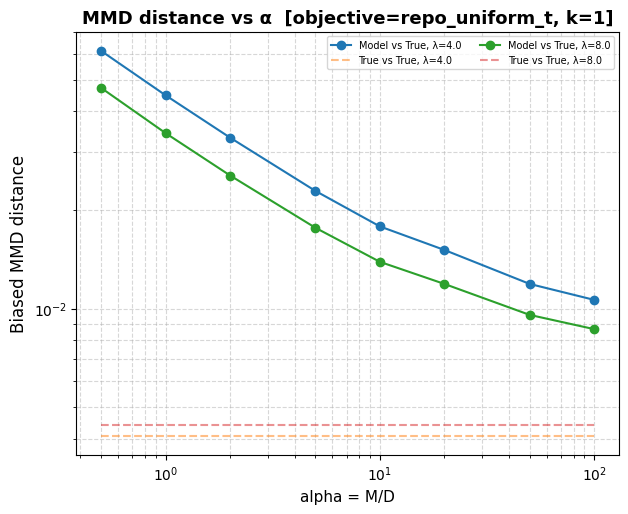

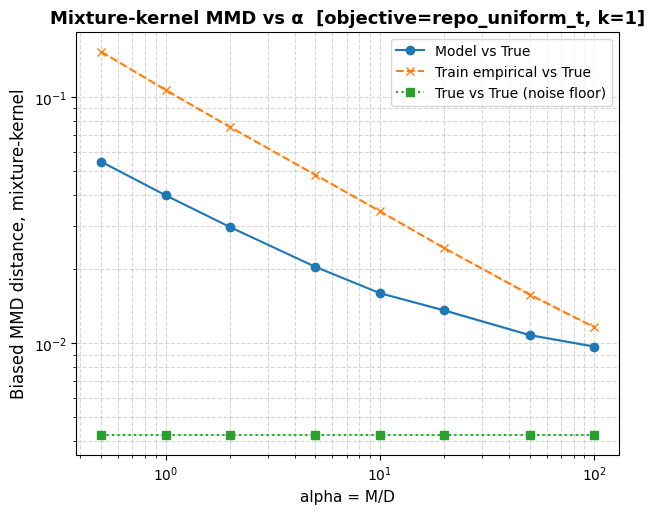

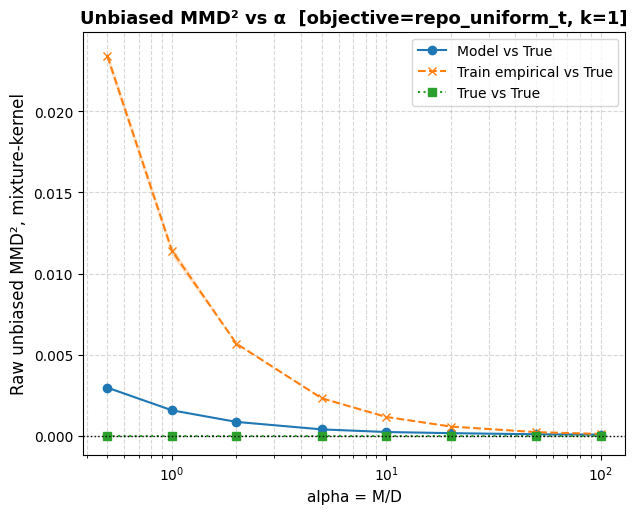

In [7]:
for obj in TRAINING_OBJECTIVES:
    for sk in sample_k_values:
        df_A = df[
            has_experiment(df, "A")
            & (df["training_objective"] == obj)
            & (df["sample_k"] == sk)
        ].copy()

        if df_A.empty:
            print(f"No Experiment-A rows for objective={obj}, k={sk}")
            continue

        subtitle = f"objective={obj}, k={sk}"

        # --- Plot 1: per-lambda biased MMD distance ---
        plt.figure(figsize=(7, 5.5))
        for lam in mmd_lambdas:
            key = lambda_key(lam)
            col_name = f"mmd_biased_lambda_{key}"
            base_col = f"baseline_mmd_biased_lambda_{key}"

            sub  = grouped_mean_sem(df_A, ["alpha"], col_name).sort_values("alpha")
            base = grouped_mean_sem(df_A, ["alpha"], base_col).sort_values("alpha")

            plt.plot(sub["alpha"],  sub["mean"],  linestyle="-",  marker="o",   label=f"Model vs True, λ={lam}")
            plt.plot(base["alpha"], base["mean"], linestyle="--", alpha=0.5,    label=f"True vs True, λ={lam}")

        plt.xscale("log")
        plt.yscale("log", nonpositive="clip")
        plt.xlabel("alpha = M/D", fontsize=11)
        plt.ylabel("Biased MMD distance", fontsize=12)
        plt.title(f"MMD distance vs α  [{subtitle}]", fontsize=13, fontweight="bold")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.legend(loc="best", fontsize=7, ncol=2)
        plt.savefig(f"figures/fig_mmd_vs_alpha_lambdas_{obj}_k{sk}.png", bbox_inches="tight")
        plt.show()

        # --- Plot 2: mixture-kernel biased MMD with all baselines ---
        plt.figure(figsize=(7, 5.5))
        for col_name, label, style in [
            ("mmd_biased_mixture",            "Model vs True",              "-o"),
            ("train_true_mmd_biased_mixture", "Train empirical vs True",    "--x"),
            ("baseline_mmd_biased_mixture",   "True vs True (noise floor)", ":s"),
        ]:
            sub = grouped_mean_sem(df_A, ["alpha"], col_name).sort_values("alpha")
            plt.plot(sub["alpha"], sub["mean"], style, label=label)
            if sub["sem"].notna().any() and (sub["sem"].fillna(0) > 0).any():
                plt.fill_between(sub["alpha"],
                                 sub["mean"] - sub["sem"],
                                 sub["mean"] + sub["sem"], alpha=0.2)

        plt.xscale("log")
        plt.yscale("log", nonpositive="clip")
        plt.xlabel("alpha = M/D", fontsize=11)
        plt.ylabel("Biased MMD distance, mixture-kernel", fontsize=12)
        plt.title(f"Mixture-kernel MMD vs α  [{subtitle}]", fontsize=13, fontweight="bold")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.legend(loc="best", fontsize=10)
        plt.savefig(f"figures/fig_mmd_vs_alpha_mixture_{obj}_k{sk}.png", bbox_inches="tight")
        plt.show()

        # --- Plot 3: unbiased MMD^2 (can be negative) ---
        plt.figure(figsize=(7, 5.5))
        for col_name, label, style in [
            ("mmd2_unbiased_mixture_raw",            "Model vs True",           "-o"),
            ("train_true_mmd2_unbiased_mixture_raw", "Train empirical vs True", "--x"),
            ("baseline_mmd2_unbiased_mixture_raw",   "True vs True",            ":s"),
        ]:
            sub = grouped_mean_sem(df_A, ["alpha"], col_name).sort_values("alpha")
            plt.plot(sub["alpha"], sub["mean"], style, label=label)
            if sub["sem"].notna().any() and (sub["sem"].fillna(0) > 0).any():
                plt.fill_between(sub["alpha"],
                                 sub["mean"] - sub["sem"],
                                 sub["mean"] + sub["sem"], alpha=0.2)

        plt.axhline(0.0, linestyle=":", linewidth=1, color="k")
        plt.xscale("log")
        plt.xlabel("alpha = M/D", fontsize=11)
        plt.ylabel("Raw unbiased MMD², mixture-kernel", fontsize=12)
        plt.title(f"Unbiased MMD² vs α  [{subtitle}]", fontsize=13, fontweight="bold")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.legend(loc="best", fontsize=10)
        plt.savefig(f"figures/fig_unbiased_mmd2_vs_alpha_mixture_{obj}_k{sk}.png", bbox_inches="tight")
        plt.show()


## 11. Dimension scaling — finite-size stress test (Experiment B)

Experiment B evaluates how the distribution-distance diagnostic changes with latent dimension $D$ at fixed $\gamma=2$, varying $\alpha=M/D$.

> Experiment B is a just the **finite-size / optimization-budget stress test**,. Changing $D$ simultaneously changes $N=\gamma D$, $M=\alpha D$, the linear parameter count $N^2$, and the number of training steps (which here scales with $N$ via `steps_for_config`). Differences across $D$ may therefore reflect any or all of: finite-size effects, optimization convergence differences, or parameter-count scaling. The $D$ dependence is not a clean scaling law. 


In [8]:
for obj in TRAINING_OBJECTIVES:
    for sk in sample_k_values:
        df_B = df[
            has_experiment(df, "B")
            & (df["training_objective"] == obj)
            & (df["sample_k"] == sk)
        ].copy()

        if df_B.empty:
            print(f"No Experiment-B rows for objective={obj}, k={sk}")
            continue

        subtitle = f"objective={obj}, k={sk}"
        unique_D = sorted(df_B["D"].unique())

        # --- Plot 1: mixture-kernel MMD vs alpha, one curve per D ---
        plt.figure(figsize=(7, 5.5))
        for d_val in unique_D:
            sub_d = df_B[df_B["D"] == d_val]
            sub   = grouped_mean_sem(sub_d, ["alpha"], "mmd_biased_mixture").sort_values("alpha")
            base  = grouped_mean_sem(sub_d, ["alpha"], "baseline_mmd_biased_mixture").sort_values("alpha")
            plt.plot(sub["alpha"],  sub["mean"],  linestyle="-",  marker="o", label=f"Model vs True (D={d_val})")
            plt.plot(base["alpha"], base["mean"], linestyle=":",  alpha=0.6,  label=f"True vs True (D={d_val})")

        plt.xscale("log")
        plt.yscale("log", nonpositive="clip")
        plt.xlabel("alpha = M/D", fontsize=11)
        plt.ylabel("Biased MMD distance, mixture-kernel", fontsize=12)
        plt.title(f"Mixture-kernel MMD vs α — finite-size stress test  [{subtitle}]",
                  fontsize=12, fontweight="bold")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.legend(loc="best", fontsize=8, ncol=2)
        plt.savefig(f"figures/fig_mmd_D_sweep_{obj}_k{sk}.png", bbox_inches="tight")
        plt.show()

        # --- Plot 2: BCE / denoising loss sanity check ---
        fig, axes = plt.subplots(1, len(unique_D), figsize=(5 * len(unique_D), 5), sharey=False)
        if len(unique_D) == 1:
            axes = [axes]
        for idx, d_val in enumerate(unique_D):
            ax = axes[idx]
            sub_d = df_B[df_B["D"] == d_val]
            sub_avg = sub_d.groupby("alpha")[["train_loss_objective", "test_loss_objective"]].mean().reset_index()
            ax.plot(sub_avg["alpha"], sub_avg["train_loss_objective"], linestyle="--", marker="x", label="Train loss")
            ax.plot(sub_avg["alpha"], sub_avg["test_loss_objective"],  linestyle="-",  marker="o", label="Test loss")
            ax.set_xscale("log")
            ax.set_xlabel("alpha = M/D", fontsize=11)
            ax.set_title(f"D = {d_val}", fontsize=12, fontweight="bold")
            ax.grid(True, which="both", linestyle="--", alpha=0.5)
            if idx == 0:
                ax.set_ylabel("BCE / denoising loss", fontsize=12)
                ax.legend(loc="best", fontsize=9)

        plt.suptitle(f"Training sanity check: BCE vs α  [{subtitle}]", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"figures/fig_bce_sanity_{obj}_k{sk}.png", bbox_inches="tight")
        plt.show()

        # --- Plot 3: model, train-empirical, and true baselines for a representative D ---
        rep_D = 80 if 80 in unique_D else unique_D[0]
        df_rep = df_B[df_B["D"] == rep_D]
        if not df_rep.empty:
            plt.figure(figsize=(7, 5.5))
            for col_name, label, style in [
                ("mmd_biased_mixture",            "Model vs True",                    "-o"),
                ("train_true_mmd_biased_mixture", "Train empirical vs True",          "--x"),
                ("model_train_mmd_biased_mixture","Model vs empirical Train",          "-.^"),
                ("baseline_mmd_biased_mixture",   "True vs True (finite-sample)",     ":s"),
            ]:
                sub = grouped_mean_sem(df_rep, ["alpha"], col_name).sort_values("alpha")
                plt.plot(sub["alpha"], sub["mean"], style, label=label)

            plt.xscale("log")
            plt.yscale("log", nonpositive="clip")
            plt.xlabel("alpha = M/D", fontsize=11)
            plt.ylabel("Biased MMD distance", fontsize=12)
            plt.title(f"All baselines (D={rep_D})  [{subtitle}]", fontsize=13, fontweight="bold")
            plt.grid(True, which="both", linestyle="--", alpha=0.5)
            plt.legend(loc="best", fontsize=9)
            plt.savefig(f"figures/fig_empirical_distribution_diagnostics_{obj}_k{sk}.png", bbox_inches="tight")
            plt.show()

            # --- Plot 4: nearest-neighbour overlap (model + fresh-true baseline) ---
            model_col = "model_nearest_train_q1_mean"
            true_col  = "true_nearest_train_q1_mean"
            excess_col = "nearest_train_q1_excess_over_true"
            if model_col in df_rep.columns:
                fig, axes2 = plt.subplots(1, 2, figsize=(12, 5))

                ax = axes2[0]
                sub_m = grouped_mean_sem(df_rep, ["alpha"], model_col).sort_values("alpha")
                sub_t = grouped_mean_sem(df_rep, ["alpha"], true_col).sort_values("alpha")
                ax.plot(sub_m["alpha"], sub_m["mean"], "-o",  label="Model nearest-train overlap")
                ax.plot(sub_t["alpha"], sub_t["mean"], "--s", label="Fresh-true nearest-train overlap")
                ax.set_xscale("log")
                ax.set_xlabel("alpha = M/D", fontsize=11)
                ax.set_ylabel("Overlap", fontsize=12)
                ax.set_title(f"Nearest training overlap  [{subtitle}]", fontsize=12, fontweight="bold")
                ax.grid(True, which="both", linestyle="--", alpha=0.5)
                ax.legend(loc="best", fontsize=9)

                ax2 = axes2[1]
                sub_e = grouped_mean_sem(df_rep, ["alpha"], excess_col).sort_values("alpha")
                ax2.plot(sub_e["alpha"], sub_e["mean"], "-o", color="tab:orange",
                         label="Model excess over fresh-true")
                ax2.axhline(0.0, linestyle=":", linewidth=1, color="k")
                ax2.set_xscale("log")
                ax2.set_xlabel("alpha = M/D", fontsize=11)
                ax2.set_ylabel("Excess overlap (model − fresh-true)", fontsize=12)
                ax2.set_title(f"Memorisation excess  [{subtitle}]", fontsize=12, fontweight="bold")
                ax2.grid(True, which="both", linestyle="--", alpha=0.5)
                ax2.legend(loc="best", fontsize=9)

                plt.tight_layout()
                plt.savefig(f"figures/fig_nearest_train_overlap_{obj}_k{sk}.png", bbox_inches="tight")
                plt.show()

            # --- Plot 5: pairwise-correlation diagnostic ---
            if "corr_relerr_model_true" in df_rep.columns:
                plt.figure(figsize=(7, 5.0))
                for col_name, label, style in [
                    ("corr_relerr_model_true",  "Model samples vs analytic RF correlation", "-o"),
                    ("corr_relerr_fresh_true",  "Fresh true vs analytic RF correlation",    "--s"),
                ]:
                    sub = grouped_mean_sem(df_rep, ["alpha"], col_name).sort_values("alpha")
                    plt.plot(sub["alpha"], sub["mean"], style, label=label)
                plt.xscale("log")
                plt.xlabel("alpha = M/D", fontsize=11)
                plt.ylabel("Relative off-diagonal Frobenius error", fontsize=12)
                plt.title(f"Pairwise-correlation recovery (D={rep_D})  [{subtitle}]",
                          fontsize=13, fontweight="bold")
                plt.grid(True, which="both", linestyle="--", alpha=0.5)
                plt.legend(loc="best", fontsize=9)
                plt.savefig(f"figures/fig_pairwise_correlation_error_{obj}_k{sk}.png", bbox_inches="tight")
                plt.show()


No Experiment-B rows for objective=repo_uniform_t, k=1


## 12. Training sanity checks and empirical-distribution diagnostics

Secondary diagnostics:

1. **BCE train/test loss**: we check that the denoising optimization is not obviously failing.
2. **Model-vs-True / Train-vs-True / True-vs-True**: separates generated-distribution quality from finite empirical training-set quality.
3. **Model-vs-Train**: proximity-to-empirical-train diagnostic 
4. **Nearest training overlap**:largest overlap between generated samples and training samples.


In [9]:
if not RUN_GAMMA_SWEEP:
    print("RUN_GAMMA_SWEEP=False: skipping Experiment C plots.")
else:
    for obj in TRAINING_OBJECTIVES:
        for sk in sample_k_values:
            df_C = df[
                has_experiment(df, "C")
                & (df["training_objective"] == obj)
                & (df["sample_k"] == sk)
            ].copy()

            if df_C.empty:
                print(f"No Experiment-C rows for objective={obj}, k={sk}")
                continue

            subtitle = f"objective={obj}, k={sk}"
            unique_gamma = sorted(df_C["gamma"].unique())

            # --- Plot 1: mixture-kernel MMD vs alpha, one panel per gamma ---
            fig, axes = plt.subplots(1, len(unique_gamma),
                                     figsize=(5.5 * len(unique_gamma), 5.5), sharey=False)
            if len(unique_gamma) == 1:
                axes = [axes]

            for ax, gval in zip(axes, unique_gamma):
                sub_g = df_C[df_C["gamma"] == gval]
                for col_name, label, style in [
                    ("mmd_biased_mixture",            "Model vs True",           "-o"),
                    ("train_true_mmd_biased_mixture", "Train vs True",           "--x"),
                    ("baseline_mmd_biased_mixture",   "True vs True",            ":s"),
                ]:
                    sub = grouped_mean_sem(sub_g, ["alpha"], col_name).sort_values("alpha")
                    ax.plot(sub["alpha"], sub["mean"], style, label=label)
                    if sub["sem"].notna().any() and (sub["sem"].fillna(0) > 0).any():
                        ax.fill_between(sub["alpha"],
                                        sub["mean"] - sub["sem"],
                                        sub["mean"] + sub["sem"], alpha=0.15)

                ax.set_xscale("log")
                ax.set_yscale("log", nonpositive="clip")
                ax.set_xlabel("alpha = M/D", fontsize=11)
                ax.set_title(f"γ = {gval}", fontsize=12, fontweight="bold")
                ax.grid(True, which="both", linestyle="--", alpha=0.5)
                ax.legend(loc="best", fontsize=8)

            axes[0].set_ylabel("Biased MMD distance, mixture-kernel", fontsize=12)
            plt.suptitle(f"Mixture-kernel MMD vs α — gamma sweep  [{subtitle}]",
                         fontsize=13, fontweight="bold")
            plt.tight_layout()
            plt.savefig(f"figures/fig_gamma_sweep_mixture_{obj}_k{sk}.png", bbox_inches="tight")
            plt.show()

            # --- Plot 2: unbiased MMD^2 vs alpha, one panel per gamma ---
            fig, axes = plt.subplots(1, len(unique_gamma),
                                     figsize=(5.5 * len(unique_gamma), 5.5), sharey=False)
            if len(unique_gamma) == 1:
                axes = [axes]

            for ax, gval in zip(axes, unique_gamma):
                sub_g = df_C[df_C["gamma"] == gval]
                for col_name, label, style in [
                    ("mmd2_unbiased_mixture_raw",            "Model vs True",  "-o"),
                    ("train_true_mmd2_unbiased_mixture_raw", "Train vs True",  "--x"),
                    ("baseline_mmd2_unbiased_mixture_raw",   "True vs True",   ":s"),
                ]:
                    sub = grouped_mean_sem(sub_g, ["alpha"], col_name).sort_values("alpha")
                    ax.plot(sub["alpha"], sub["mean"], style, label=label)

                ax.axhline(0.0, linestyle=":", linewidth=1, color="k")
                ax.set_xscale("log")
                ax.set_xlabel("alpha = M/D", fontsize=11)
                ax.set_title(f"γ = {gval}", fontsize=12, fontweight="bold")
                ax.grid(True, which="both", linestyle="--", alpha=0.5)
                ax.legend(loc="best", fontsize=8)

            axes[0].set_ylabel("Raw unbiased MMD², mixture-kernel", fontsize=12)
            plt.suptitle(f"Unbiased MMD² vs α — gamma sweep  [{subtitle}]",
                         fontsize=13, fontweight="bold")
            plt.tight_layout()
            plt.savefig(f"figures/fig_gamma_sweep_unbiased_mmd2_{obj}_k{sk}.png", bbox_inches="tight")
            plt.show()


No Experiment-C rows for objective=repo_uniform_t, k=1


### 12b. Time-sliced denoising diagnostic (secondary)

Average loss over $t\sim U(0,1)$ can look fine even if the model is poor at high masking
fractions — exactly where sequential sampling starts. We do a quick secondary check across 
(`t_grid = [0.1, 0.3, 0.5, 0.7, 0.9]`) of `repo_uniform_t` train/test loss and accuracy at a
few fixed masking fractions $t$, close to the `test_step` time-sliced pattern.

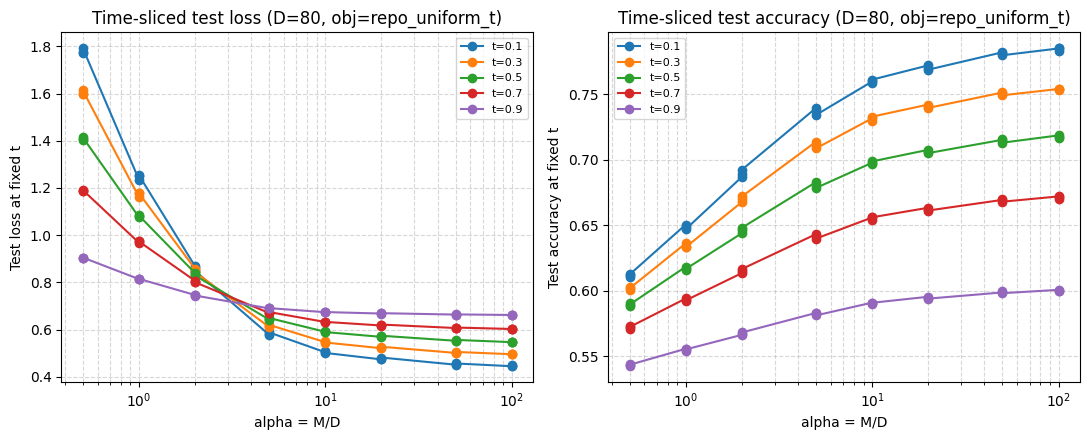

In [10]:
if not df_timesliced.empty:
    for obj in TRAINING_OBJECTIVES:
        df_ts = df_timesliced[df_timesliced["training_objective"] == obj]
        if df_ts.empty:
            continue
        rep_D_ts = 80 if 80 in df_ts["D"].unique() else sorted(df_ts["D"].unique())[0]
        sub = df_ts[(df_ts["D"] == rep_D_ts) & (df_ts["gamma"] == 2.0)]
        if sub.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        for t_val in t_grid:
            sub_t = sub[sub["t_val"] == t_val].sort_values("alpha")
            axes[0].plot(sub_t["alpha"], sub_t["test_loss_t"], marker="o", label=f"t={t_val}")
            axes[1].plot(sub_t["alpha"], sub_t["test_acc_t"],  marker="o", label=f"t={t_val}")

        axes[0].set_xscale("log")
        axes[0].set_xlabel("alpha = M/D")
        axes[0].set_ylabel("Test loss at fixed t")
        axes[0].set_title(f"Time-sliced test loss (D={rep_D_ts}, obj={obj})")
        axes[0].grid(True, which="both", linestyle="--", alpha=0.5)
        axes[0].legend(fontsize=8)

        axes[1].set_xscale("log")
        axes[1].set_xlabel("alpha = M/D")
        axes[1].set_ylabel("Test accuracy at fixed t")
        axes[1].set_title(f"Time-sliced test accuracy (D={rep_D_ts}, obj={obj})")
        axes[1].grid(True, which="both", linestyle="--", alpha=0.5)
        axes[1].legend(fontsize=8)

        plt.tight_layout()
        plt.savefig(f"figures/fig_time_sliced_diagnostic_{obj}.png", bbox_inches="tight")
        plt.show()
else:
    print("No time-sliced diagnostic rows (COMPUTE_TIME_SLICED_DIAGNOSTIC was False, "
          "or no repo_uniform_t rows were run).")


## 13. Interpretation and discussion

> **Does it work?** Model-vs-True MMD should decrease with $\alpha$ and approach the
> True-vs-True baseline. A plateau above the baseline indicates possible
> model/sampler/optimization/finite-size limitations is not proof of an asymptotic
> capacity threshold.


- **BCE vs. MMD mismatch**: A smaller masked-coordinate BCE does not automatically imply that the full generative sampler has the correct joint distribution. BCE is a local conditional diagnostic; MMD compares generated samples with true samples globally.
- **MMD vs. $\alpha$**: If Model-vs-True MMD decreases with $\alpha=M/D$, this is evidence that the generated distribution becomes closer to the true finite-$F$ hidden-manifold law as more training samples are provided.
- **Train-vs-True baseline**: This baseline tells us whether the model is doing better or worse than the empirical training distribution as an approximation to $P_F$. It is essential for separating generalization from finite-sample memorization.
- **Plateau warning**: A residual gap above the True-vs-True baseline is compatible with limited linear-model capacity, but it does not prove it. The gap may also come from optimization error, objective/sampler mismatch, fixed-mask training mismatch, sampler bias, finite-sample MMD effects, or the chosen kernel scale.
- **Linear backbone caveat**: The hidden-manifold sign model induces nontrivial dependencies among visible bits. A time-independent linear visible-coordinate denoiser may capture part of the structure but need not represent the full family of masked conditional distributions required to reproduce $P_F$.
- **Negative unbiased estimates**: Raw unbiased MMD$^2$ can be slightly negative at finite sample size when two samples are drawn from close or identical distributions. This is statistical noise.
- **Mixture-kernel MMD**: The mixture-kernel MMD averages $\mathrm{MMD}^2(\lambda)$ uniformly over $\lambda \in \{0.5,1,2,4,8,16\}$. It is thus valid as a positive mixture-kernel if weights are non-negative and normalized. It is a scalar and we need  inspect per-$\lambda$ curves to check whether results are dominated by a single scale.

### Where the plot-axis formulas and the negative-baseline note live

The full documentation of the plotted quantities is kept in
**`mmd_results_presentation_1.ipynb`** (same folder), to avoid duplicating it here:

- **"Excess over fresh true"** (nearest-neighbour memorization diagnostic):
  `nearest_train_q1_excess_over_true = model_nearest_train_q1_mean − true_nearest_train_q1_mean`,
  i.e. how much closer a generated sample sits to its nearest training point than a *fresh true*
  sample does. Zero (or slightly negative, from finite-sample fluctuation) means no memorization
  excess.
- **Negative baseline values**: the unbiased MMD$^2$ is a U-statistic with zero mean when the two
  samples share the same law, so *individual estimates can legitimately be negative* at finite
  sample size. This is expected behaviour of the honest estimator, not a bug.

The residual Model-vs-True gap above the True-vs-True floor at large $\alpha$ remains an
**open question** — capacity limits, optimization error, objective/sampler mismatch, and kernel
finite-sample effects are all still on the table.


## Retrieval dynamics in the random-feature setup: one-shot vs. time-integrated (Figure 7 style)

Extension of Figure 7 of the original experiments write-up to the **random-feature data** used
throughout this notebook: retrieval dynamics of the magnetization for learned weights with
$\lambda = 0$ and $\lambda = 0.01$ (L2 regularization) and for **Hebbian** weights, in both
**one-shot** and **time-integrated** (sequential unmasking) retrieval.

Setup — everything matches the sweep above:

- Data: `RandomFeaturesDataset` at fixed $(D, \gamma)$; the models are trained on the *same*
  $M = \alpha D$ training patterns that define the Hebbian couplings.
- Each retrieval trajectory starts from a training pattern $\xi$ with a fraction $t_0$ of spins
  masked, so the **initial magnetization** is $m_{\mathrm{in}} = 1 - t_0$ (unmasked spins agree
  with $\xi$, masked spins contribute 0).
- **One-shot**: all masked spins are decoded simultaneously from the conditionals
  (`mask_and_sample_oneshot`). **Time-integrated**: the sequential unmasking sampler reveals one
  spin at a time (`mask_and_sample`, measured law is $P_{\theta,k=1}$).
- All decoding is **fair** (categorical sampling from the conditionals) for both the learned and
  the Hebbian models, consistent with the rest of the notebook.
- **Final magnetization**: $m_{\mathrm{fin}} = \frac{1}{N}\sum_i x_i^{\mathrm{fin}} \xi_i$,
  averaged over trajectories (1000 for one-shot, 200 for time-integrated, as in the original
  figure; reduced automatically in the fast run modes).
- Hebbian model: a `MaskedDiffusion` linear backbone with
  $W_{ij} = \beta_{\mathrm{heb}} \frac{1}{N} \sum_\mu \xi_i^\mu \xi_j^\mu$ (zero diagonal),
  $V = 0$, no bias. $\beta_{\mathrm{heb}}$ acts as an inverse temperature for the fair
  (sigmoid) decoding; it has no analogue in the learned models, so its value is a choice —
  we use $\beta_{\mathrm{heb}} = 4$ and it should be kept fixed across comparisons.

> **Open question / caveat**: the DMFT prediction (coupled ODEs for the magnetization and the
> crosstalk-noise variance) is not overlaid — the ODE solver for the masked-Hopfield DMFT has
> not been ported to this repo (theory in `notes/notes_dmft_masked_hopfield.typ`), and its
> extension from Hopfield patterns to random-feature data is itself open.


Training retrieval model l2reg=0.0 (N=160, M=160, steps=3000) ...


    Step 500/3000 | Loss: 0.3966


    Step 1000/3000 | Loss: 0.3829


    Step 1500/3000 | Loss: 0.3810


    Step 2000/3000 | Loss: 0.3851


...

Retrieval: learned, $\lambda=0.0$ | time-integrated (200 trajectories) ...


Retrieval: learned, $\lambda=0.01$ | one-shot (1000 trajectories) ...


Retrieval: learned, $\lambda=0.01$ | time-integrated (200 trajectories) ...


Retrieval: Hebbian | one-shot (1000 trajectories) ...


Retrieval: Hebbian | time-integrated (200 trajectories) ...


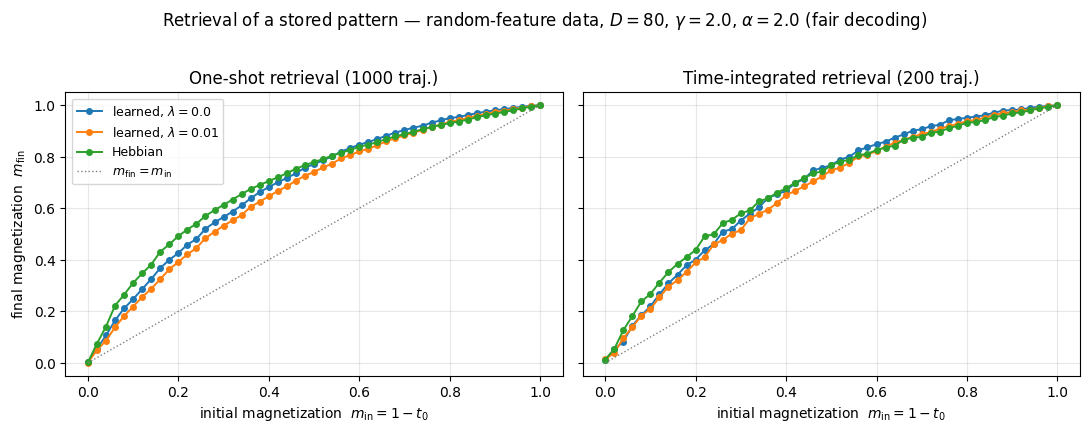

In [11]:
# ---------------------------------------------------------------------------
# Figure-7-style retrieval in the random-feature setup.
# Trains three weight matrices on the same RF training set, then measures
# final vs. initial magnetization under one-shot and sequential (fair) decoding.
# ---------------------------------------------------------------------------
retrieval_D     = 80
retrieval_gamma = 2.0
retrieval_alpha = 2.0          # alpha = M/D, same convention as the sweep
retrieval_l2regs = [0.0, 0.01]
beta_hebbian    = 4.0          # inverse temperature of the Hebbian sigmoid conditionals

if FAST_DEBUG:
    n_traj_oneshot, n_traj_seq, t0_step = 100, 20, 0.1
elif MACBOOK_30MIN_RUN:
    n_traj_oneshot, n_traj_seq, t0_step = 300, 60, 0.05
else:
    n_traj_oneshot, n_traj_seq, t0_step = 1000, 200, 0.02   # original Figure-7 counts

retrieval_N = int(round(retrieval_gamma * retrieval_D))
retrieval_M = int(round(retrieval_alpha * retrieval_D))
t0_grid     = np.arange(0.0, 1.0001, t0_step)

# --- data: same construction/seeding style as the sweep ---
retrieval_seed = base_seed + 987_654
torch.manual_seed(retrieval_seed)
np.random.seed(retrieval_seed)
retrieval_dataset = RandomFeaturesDataset(
    n_visible=retrieval_N, n_hidden=retrieval_D,
    num_samples=retrieval_M, act=torch.sign)
retrieval_dataset.data[retrieval_dataset.data == 0.0] = 1.0
patterns = retrieval_dataset.data            # [M, N], the stored patterns

# --- weight matrices ---
retrieval_models = {}

for l2 in retrieval_l2regs:
    cfg = SimpleNamespace(
        L=retrieval_N, alpha=retrieval_M / retrieval_N, model="linear",
        l2reg=l2, lr=0.005, epochs=1,
        batch_size=min(retrieval_M, 512),
        freeze_mask_weights=True, bias=False, pbar=False)
    steps = steps_for_config(retrieval_N, retrieval_M, cfg.batch_size)
    print(f"Training retrieval model l2reg={l2} (N={retrieval_N}, M={retrieval_M}, steps={steps}) ...")
    model, _ = train_model(
        Subset(retrieval_dataset, list(range(retrieval_M))), cfg, steps,
        objective="repo_uniform_t", K_visible=int(round(kappa * retrieval_D)),
        t_mask=0.5, seed=retrieval_seed + int(l2 * 10_000), device=train_device)
    retrieval_models[rf"learned, $\lambda={l2}$"] = model.cpu().eval()

# Hebbian couplings on the same patterns: W = beta/N * Xi^T Xi, zero diagonal, V = 0.
heb_cfg = SimpleNamespace(
    L=retrieval_N, alpha=retrieval_M / retrieval_N, model="linear",
    l2reg=0.0, lr=0.005, epochs=1, batch_size=1,
    freeze_mask_weights=True, bias=False, pbar=False)
heb_model = MaskedDiffusion(heb_cfg).eval()
with torch.no_grad():
    W_heb = beta_hebbian * (patterns.t() @ patterns) / retrieval_N
    W_heb.fill_diagonal_(0.0)
    heb_model.backbone.W.copy_(W_heb)
    heb_model.backbone.V.zero_()
retrieval_models["Hebbian"] = heb_model

# --- retrieval sweep over t0 ---
def retrieval_curve(model, n_traj, oneshot: bool):
    """m_fin vs m_in for one model: start from stored patterns, mask t0*N spins,
    decode fairly, and measure the overlap with the original pattern."""
    m_in, m_fin = [], []
    gen = torch.Generator().manual_seed(retrieval_seed + (1 if oneshot else 2))
    for t0 in t0_grid:
        T0 = int(round(t0 * retrieval_N))
        x0 = patterns[torch.randint(0, retrieval_M, (n_traj,), generator=gen)]
        with torch.no_grad():
            if T0 == 0:
                xt = x0.clone()
            elif oneshot:
                xt, _ = model.mask_and_sample_oneshot(x0, T0=T0, decoding_strategy="fair")
            else:
                xt, _ = model.mask_and_sample(x0, T0=T0, decoding_strategy="fair")
        m_in.append(1.0 - t0)
        m_fin.append((xt * x0).mean(dim=1).mean().item())
    return np.array(m_in), np.array(m_fin)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
colors = dict(zip(retrieval_models, ["tab:blue", "tab:orange", "tab:green"]))

for label, model in retrieval_models.items():
    for ax, oneshot, n_traj in ((axes[0], True, n_traj_oneshot),
                                (axes[1], False, n_traj_seq)):
        print(f"Retrieval: {label} | {'one-shot' if oneshot else 'time-integrated'} "
              f"({n_traj} trajectories) ...")
        m_in, m_fin = retrieval_curve(model, n_traj, oneshot)
        ax.plot(m_in, m_fin, "o-", ms=4, lw=1.4, color=colors[label], label=label)

for ax, title in zip(axes, [f"One-shot retrieval ({n_traj_oneshot} traj.)",
                            f"Time-integrated retrieval ({n_traj_seq} traj.)"]):
    ax.plot([0, 1], [0, 1], ls=":", c="gray", lw=1, label=r"$m_{\rm fin}=m_{\rm in}$")
    ax.set_xlabel(r"initial magnetization  $m_{\rm in} = 1 - t_0$")
    ax.set_title(title)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"final magnetization  $m_{\rm fin}$")
axes[0].legend(fontsize=9)
fig.suptitle(
    rf"Retrieval of a stored pattern — random-feature data, "
    rf"$D={retrieval_D}$, $\gamma={retrieval_gamma}$, $\alpha={retrieval_alpha}$ (fair decoding)",
    y=1.02)
fig.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/fig_retrieval_rf_oneshot_vs_timeintegrated.png", dpi=200, bbox_inches="tight")
plt.show()


In [12]:
# === Execution Run Status ===

# ---------------------------------------------------------------------------
# Integrity checks: fail loudly if the sweep produced malformed output.
# ---------------------------------------------------------------------------
assert len(df) > 0, "No results were collected — the sweep produced an empty DataFrame."
assert df["mmd_biased_mixture"].notna().all(), "Found NaN in mmd_biased_mixture."
assert df["baseline_mmd_biased_mixture"].notna().all(), "Found NaN in baseline_mmd_biased_mixture."
assert df["training_objective"].isin(TRAINING_OBJECTIVES).all(), \
    "Found training_objective values outside TRAINING_OBJECTIVES."

print("=== Execution Run Status ===")
print(f"FAST_DEBUG:        {FAST_DEBUG}")
print(f"MACBOOK_30MIN_RUN: {MACBOOK_30MIN_RUN}")
print(f"FINAL_RUN:         {FINAL_RUN}")
print(f"run_mode:          {run_mode}")
print(f"train_device:      {train_device}")
print(f"mmd_device:        {mmd_device}")
print(f"PREFER_MPS_FOR_TRAINING: {PREFER_MPS_FOR_TRAINING}")
print(f"USE_MPS_FOR_MMD:   {USE_MPS_FOR_MMD}")
print(f"TRAINING_OBJECTIVES: {TRAINING_OBJECTIVES}")
print(f"sample_k_values:   {sample_k_values}")
print(f"n_repeats:         {n_repeats}")
print(f"n_mmd_samples:     {n_mmd_samples}")
print(f"mmd_chunk_size:    {mmd_chunk_size}")
print(f"n_eval_mc:         {n_eval_mc}")
print(f"checkpoint_path:   {checkpoint_path}")
print()
print(f"number of result rows:      {len(df)}")
print(f"number of time-sliced rows: {len(df_timesliced)}")

if len(df) > 0:
    print(f"objectives run:    {sorted(df['training_objective'].unique())}")
    print(f"sample_k run:      {sorted(df['sample_k'].unique())}")
    print(f"D values run:      {sorted(df['D'].unique())}")
    print(f"gamma values run:  {sorted(df['gamma'].unique())}")
    print(f"alpha values run:  {sorted(df['alpha'].unique())}")

print("============================")

if FAST_DEBUG:
    print("\n[Warning] FAST_DEBUG=True: smoke-test only. "
          "Results must NOT be used for quantitative research claims.")
elif MACBOOK_30MIN_RUN:
    print("\nThese are MacBook-local preview results only. They are useful for "
          "checking qualitative trends and pipeline behavior, but they are not "
          "final quantitative evidence.")
elif not FINAL_RUN:
    print("\n[Warning] FINAL_RUN=False: single-repeat results. "
          "Set FINAL_RUN=True before making final quantitative claims.")


=== Execution Run Status ===
FAST_DEBUG:        False
MACBOOK_30MIN_RUN: False
FINAL_RUN:         True
run_mode:          full_final
train_device:      cpu
mmd_device:        cpu
PREFER_MPS_FOR_TRAINING: False
USE_MPS_FOR_MMD:   False
TRAINING_OBJECTIVES: ['repo_uniform_t']
sample_k_values:   [1]
n_repeats:         3
n_mmd_samples:     100000
mmd_chunk_size:    1024
n_eval_mc:         50
checkpoint_path:   results/results_mmd_distribution_distance_full_checkpoint.csv

number of result rows:      24
number of time-sliced rows: 120
objectives run:    ['repo_uniform_t']
sample_k run:      [np.int64(1)]
D values run:      [np.int64(80)]
gamma values run:  [np.float64(2.0)]
alpha values run:  [np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(50.0), np.float64(100.0)]
